In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.20


# Python libraries

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle

## for kriging plotting
from scipy.spatial import cKDTree
from pykrige.ok import OrdinaryKriging

import cartopy.crs as ccrs
import cmocean.cm as cmo

try:
    import proplot as plot
except ImportError:
    plot = None  # proplot is optional; install via: pip install proplot==0.9.7
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need
%load_ext autoreload
%autoreload 2
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS import predict_T_from_RI, predict_RI_from_T
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.data import MahalanobisOutlierDetector, build_invT_inputData, build_fwd_data
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial

0.1.2


# Cosmetic settings

In [3]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

# Miscellaneous functions

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


import inspect
from IPython.display import Markdown
def display_function_signature(func):
    sig = inspect.signature(func)
    params = []
    for param_name, param in sig.parameters.items():
        if param.default != inspect.Parameter.empty:
            params.append(f"    {param_name}={param.default}")
        else:
            params.append(f"    {param_name}")

    formatted = f"{func.__name__}(\n" + ",\n".join(params) + "\n)"
    return Markdown(f"```python\n{formatted}\n```")

In [5]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.021,0.105), #(0.021,0.105)  <--- recalculated from the Fig S2 in O'Brien et al., 2017 | (0.0170,0.19) <--- shown in the main text of O'Brien et al., 2017
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

In [6]:
# ── sig-fig helpers (self-contained) ─────────────────────────────────────────

def _n_decimals(scale: float) -> int:
    """Decimal places needed to show `scale` to 1-2 sig figs (GUM §7.2.6)."""
    if not math.isfinite(scale) or scale <= 0:
        return 3
    mag = math.floor(math.log10(abs(scale)))
    first_digit = int(abs(scale) / 10 ** mag)
    return max(0, 1 - mag) if first_digit <= 3 else max(0, -mag)


def _format_stat(median: float, std: float, fmt: str | None = None) -> str:
    """Return 'median ± std' formatted to appropriate significant figures.
    Uncertainty drives precision: 1 sig fig on std (2 if leading digit <= 3).

    Parameters
    ----------
    fmt : str or None
        Optional format spec override (e.g. ``'.3f'``, ``'.2e'``).
        When given, both median and std are formatted with this spec and
        the automatic sig-fig logic is bypassed entirely.
    """
    if fmt is not None:
        return f"{median:{fmt}} ± {std:{fmt}}"
    if not math.isfinite(std) or std <= 0:
        return f"{median:.3g}"
    n_dec = _n_decimals(std)
    fmt   = f".{n_dec}f"
    return f"{round(median, n_dec):{fmt}} ± {round(std, n_dec):{fmt}}"


# ── formatting helpers ────────────────────────────────────────────────────────

def _fmt_r2(r2: float) -> str:
    """R² precision driven by unexplained variance; capped at 3 d.p."""
    n = min(_n_decimals(1 - r2), 3)
    return f"{round(r2, n):.{n}f}"


def _fmt_rmse(rmse: float) -> str:
    """RMSE always reported to 2 sig figs."""
    mag = math.floor(math.log10(abs(rmse)))
    n   = max(0, 1 - mag)
    return f"{round(rmse, n):.{n}f}"


def _fmt_delta_r2(dr2: float) -> str:
    if abs(dr2) == 0:
        return f"{dr2:.3f}"
    n = _n_decimals(abs(dr2))
    return f"{round(dr2, n):.{n}f}"


def _fmt_p(p: float) -> str:
    if p < 0.001:
        return "<0.001"
    mag = math.floor(math.log10(abs(p)))
    return f"{round(p, -mag + 1):.2e}"


def _fmt_coef(coef: float, ci_halfwidth: float) -> str:
    """coef ± 95% CI, precision driven by CI half-width."""
    sigma = ci_halfwidth / 1.96
    return _format_stat(coef, sigma)


def _fmt_delta(delta: float) -> str:
    """Delta to 2 sig figs with sign."""
    if abs(delta) == 0:
        return "+0.000"
    d_mag = math.floor(math.log10(abs(delta)))
    nd    = max(0, 1 - d_mag)
    return f"{delta:+.{nd}f}"


## Logistic equations

In [7]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def inverse_generalized_logistic_model_fixed_upper(y, x0, b, k, v):
    """
    Inverse of the generalized logistic model function with a fixed upper asymptote.
    Parameters:
    - y: The output value for which to compute the inverse.
    - x0: Inflection point
    - b: Lower asymptote (left asymptote)
    - k: Slope
    - v: Shape parameter
    Returns:
    - The input value x corresponding to the output y in the generalized logistic model.
    """
    term = ((1 - b) / (y - b))**v - 1
    x = x0 - (np.log(term) / k)
    return x

In [8]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

# Set local path

In [9]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# Detect environment
IN_DOCKER = Path("/home/micromamba/app").exists()

if IN_DOCKER:
    local_onedrive_path = Path("/mnt/onedrive")
    local_github_path = Path("/home/micromamba/app")
    print(local_github_path)
else:
    local_onedrive_path = Path.home() / "OneDrive"   # adjust if needed
    local_github_path = Path.home() / "Documents/GitHub/TEXAS"
    print(local_github_path)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app


In [10]:
### Regression dataset compilation
fpath = os.path.join(local_github_path,'data/spreadsheets')
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,scaledRI_noCren,scaledRI_noCren_cren2,scaledRI_noCren_cren3,scaledRI_noCren_cren5,scaledRI_noCrens,t_sf2tc_avg,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.014931,0.026003,0.018622,0.012717,0.014819,-1.636017,1.761114,1.533491,1.647303,1.874926
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.023083,0.041645,0.029270,0.019371,0.024862,-1.586854,1.575668,1.421365,1.498516,1.652819
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.015386,0.027329,0.019367,0.012997,0.015979,-1.692642,1.648903,1.464398,1.556650,1.741155
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.012017,0.022152,0.015395,0.009990,0.013538,-1.498910,1.547138,1.425926,1.486532,1.607744
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.012829,0.022799,0.016152,0.010835,0.013332,-1.651191,1.604469,1.425698,1.515084,1.693855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,0.170341,0.324512,0.221731,0.139506,0.208941,22.000000,1.673550,1.594122,1.633836,1.713264
1572,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.182046,0.341748,0.235280,0.150106,0.217802,25.000000,1.793452,1.683386,1.738419,1.848485
1573,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.212344,0.333060,0.252582,0.188200,0.177191,32.000000,2.269506,1.779857,2.024682,2.514331
1574,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.434933,0.717056,0.528974,0.378508,0.444013,36.000000,2.414045,1.989968,2.202006,2.626083


In [11]:
gridded_combined_df.groupby('organism_broadClass4').describe()['TEX86']

,count,mean,std,min,25%,50%,75%,max
organism_broadClass4,,,,,,,,
Coretop,1513.0,0.522263,0.128165,0.293000,0.410686,0.507700,0.628371,0.886000
Group 1.1b,12.0,0.878518,0.188628,0.320388,0.861690,0.943443,0.986874,0.994442
Marine Group 1.1a,33.0,0.522152,0.112942,0.339403,0.444356,0.508786,0.592257,0.767980
Mesocosm,8.0,0.591488,0.178141,0.334578,0.476640,0.608391,0.721737,0.813041
Non-marine Group 1.1a,10.0,0.586409,0.140227,0.320388,0.517301,0.592712,0.641534,0.806931


In [12]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Calibration posteriors

In [13]:
# # Save data for Stan
# y_params = ['scaledRI','scaledRI_cren3']
# for y_param in y_params:
#     cul_df = gridded_combined_df[gridded_combined_df['datatype']=='culture'].dropna(subset=[y_param,'SST']).reset_index(drop=True)
#     meso_df = gridded_combined_df[gridded_combined_df['datatype']=='mesocosm'].dropna(subset=[y_param,'SST']).reset_index(drop=True)
#     data = build_fwd_data(
#         t_cul = cul_df['SST'].values,
#         proxy_cul = cul_df[y_param].values,
#         t_meso = meso_df['SST'].values,
#         proxy_meso = meso_df[y_param].values,
#     )

#     stan_file_name = 'gen_logi_fixed_culmeso'
#     gen_logi_fixed_cul_meso_post_ds, diag = get_posterior(
#                                                 data=data, 
#                                                 proxy_name=y_param,
#                                                 stan_file=stan_file_name,
#                                                 temptype='cultureT')


#     # Save posteriors
#     save_posterior(gen_logi_fixed_cul_meso_post_ds,filename_suffix="_032326")



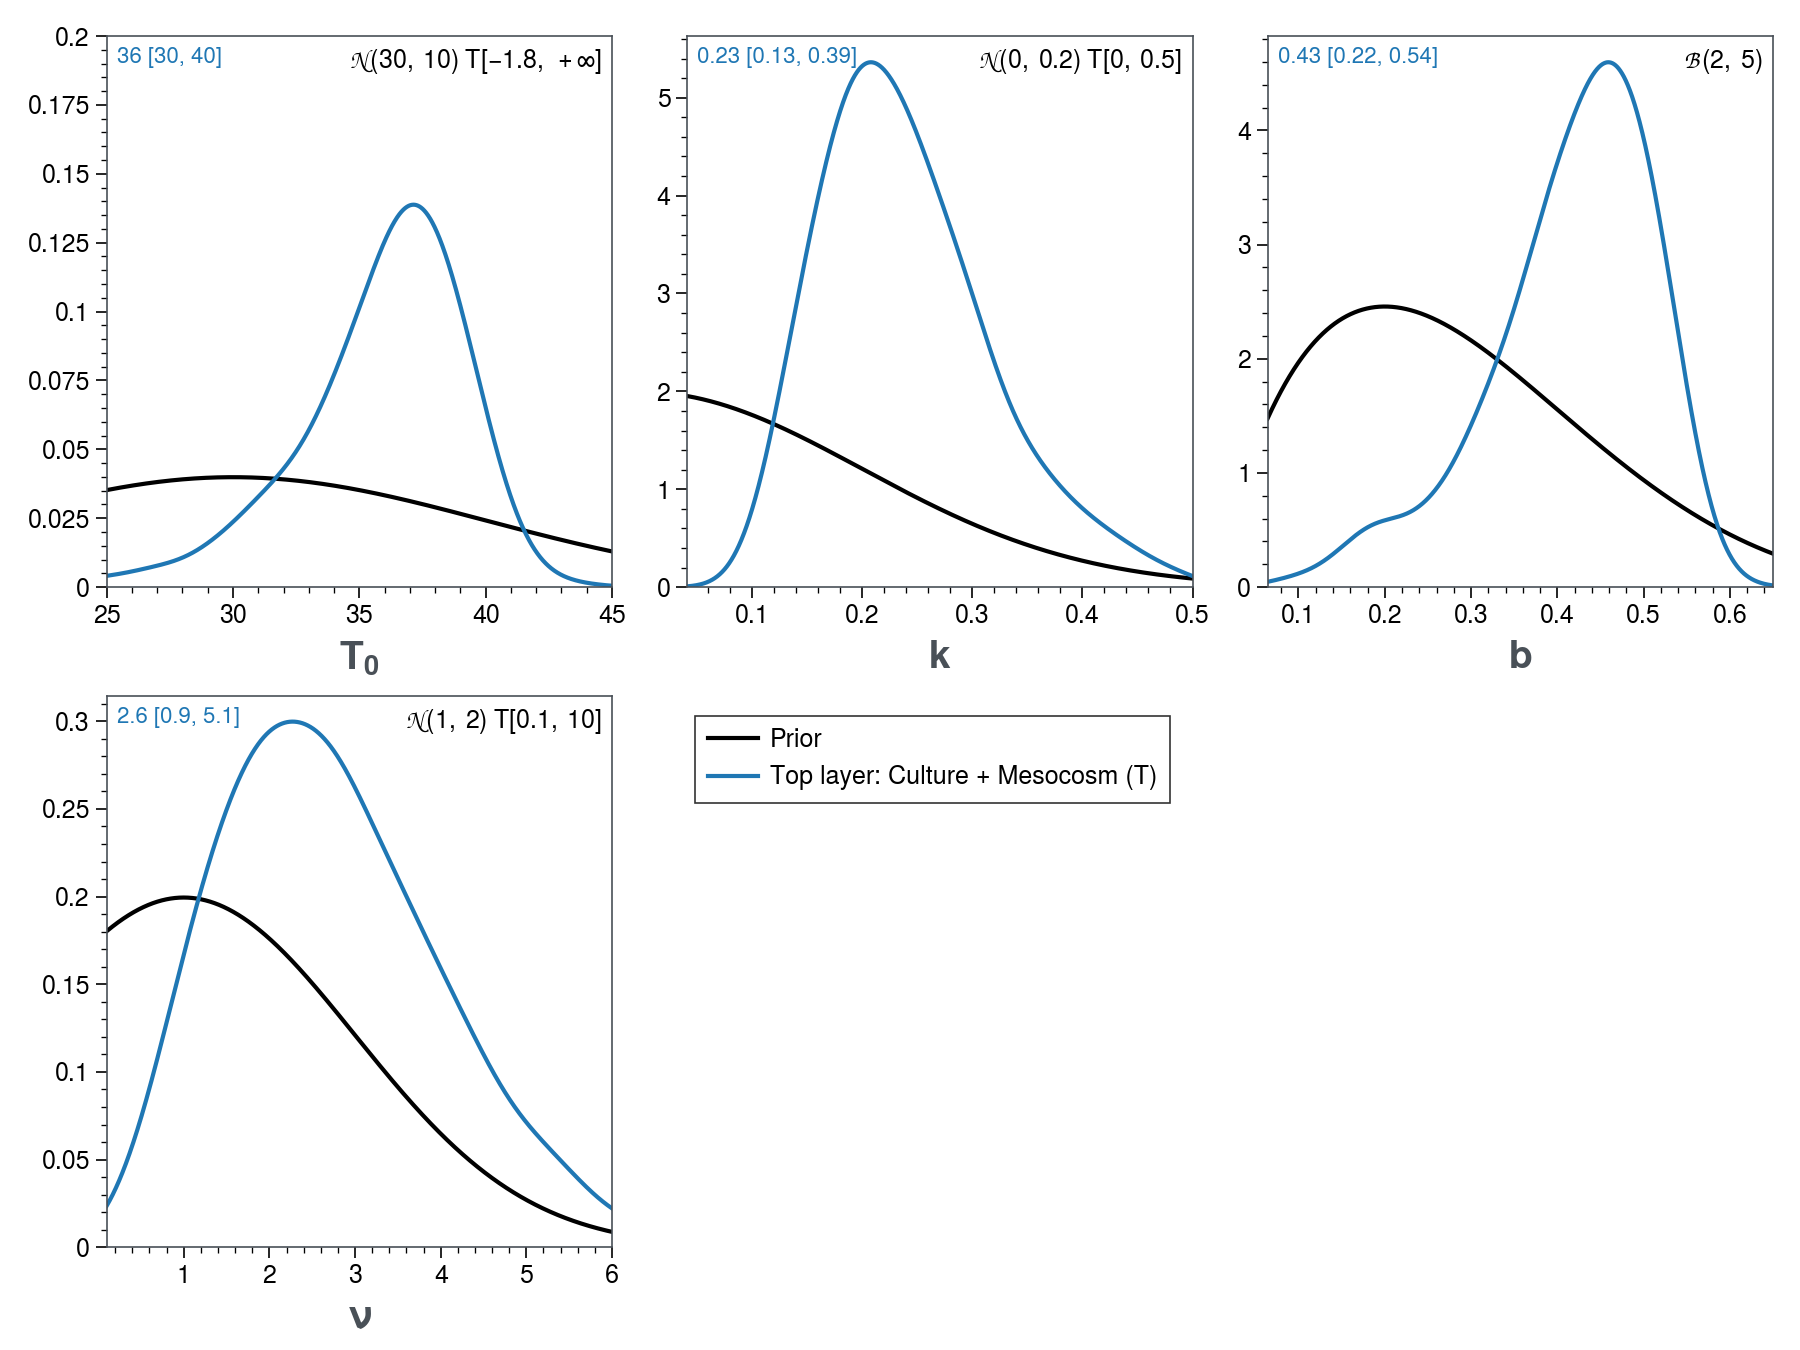

In [14]:
legend_labels = ['Top layer: Culture + Mesocosm (T) | scaledRI', 
                 'Top layer: Culture + Mesocosm (T) | scaledRI_cren3',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────                                                                                                                 
post_fwd_032326 = [
    "gen_logi_fixed_culmeso_cultureT_scaledRI_cren3_032326",                                                                                              
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd_032326,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=False,
    show_prior_expression=True,
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,0.2)
# axs[0,1].set_xlim(0,0.4)
# axs[0,2].set_xlim(0.38,0.46)
# axs[1,0].set_xlim(0,6)
# axs[1,0].set_ylim(0,1)
# axs[1,1].set_xlim(0,6)
axs[1,1].set_ylim(0,0.5)
axs[1,2].set_xlim(-0.01,0)
axs[1,2].set_ylim(0,1200)
fig.tight_layout()

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color='gray7', fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color='gray7', fontweight='bold')
    
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, color='gray7')
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, color='gray7')
    
    ax.spines[:].set_color('gray7')
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)
    
h, l = axs[0,0].get_legend_handles_labels()
fig.legend(h,['Prior','Top layer: Culture + Mesocosm (T)'],bbox_to_anchor=(0.65, 0.47))
# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixA_culmesoT_prior_distributions.pdf'),dpi=300,tight_layout=True,)

# Coretop analysis

In [15]:
coretop_df = gridded_combined_df[gridded_combined_df['datatype']=='coretop'].dropna(subset=['no3_sf2tc_avg', 'SST']).reset_index(drop=True)
coretop_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,scaledRI_noCren,scaledRI_noCren_cren2,scaledRI_noCren_cren3,scaledRI_noCren_cren5,scaledRI_noCrens,t_sf2tc_avg,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.014931,0.026003,0.018622,0.012717,0.014819,-1.636017,1.761114,1.533491,1.647303,1.874926
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.023083,0.041645,0.029270,0.019371,0.024862,-1.586854,1.575668,1.421365,1.498516,1.652819
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.015386,0.027329,0.019367,0.012997,0.015979,-1.692642,1.648903,1.464398,1.556650,1.741155
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.012017,0.022152,0.015395,0.009990,0.013538,-1.498910,1.547138,1.425926,1.486532,1.607744
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.012829,0.022799,0.016152,0.010835,0.013332,-1.651191,1.604469,1.425698,1.515084,1.693855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,84.125,46.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,0.027670,0.047611,0.034317,0.023682,0.026794,-1.237260,1.680000,1.445333,1.562667,1.797333
1509,84.875,40.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,0.038530,0.067211,0.048090,0.032793,0.038654,-1.373924,1.635830,1.424415,1.530122,1.741537
1510,86.875,-146.125,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,0.083740,0.122595,0.096692,0.075969,0.054241,-1.474355,1.987319,1.454710,1.721014,2.253623
1511,87.125,104.625,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,0.075465,0.112769,0.087900,0.068004,0.051712,-1.377392,2.089165,1.560948,1.825056,2.353273


In [29]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# reg_data = coretop_df[[*temp_params, *y_params]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                                                                                                                                                         
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(                                                                                                                                               
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                                                                                                                                                            
                    
#         data = build_fwd_data(                                                                                                                                                       
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,                                                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors                                                                                                            
#         )                                                                                                                                                                            
                                                                                                                                                                                    
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,                                                                                                                                                      
#             stan_file='gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),                                                                                                                                                          
#         )                                                                                                                                                                            
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [30]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['gdgt23ratio']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                                                                                                                                                         
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(                                                                                                                                               
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                                                                                                                                                            
                    
#         data = build_fwd_data(                                                                                                                                                       
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors                                                                                                            
#         )                                                                                                                                                                            
                                                                                                                                                                                    
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,                                                                                                                                                      
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                                                                                                                                                                   
#         )                                                                                                                                                                            
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [31]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                                                                                                                                                         
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(                                                                                                                                               
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                                                                                                                                                            
                    
#         data = build_fwd_data(                                                                                                                                                       
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.8                                                              
#         )                                                                                                                                                                            
                                                                                                                                                                                      
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                                                                                                                                                                   
#         )                                                                                                                                                                            
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [32]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                                                                                                                                                         
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(                                                                                                                                               
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                                                                                                                                                            
                    
#         data = build_fwd_data(                                                                                                                                                       
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.0
                                                                                                                      
#         )                                                                                                                                                                            
                                                                                                                                                                                      
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                                                                                                                                                                   
#         )                                                                                                                                                                            
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [33]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg','gdgt23ratio']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                                                                                                                                                         
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(                                                                                                                                               
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                                                                                                                                                            
                    
#         data = build_fwd_data(                                                                                                                                                       
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,   
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.8                                                                                                           
#         )                                                                                                                                                                            
                                                                                                                                                                                    
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,                                                                                                                                                      
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                                                                                                                                                                   
#         )                                                                                                                                                                            
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [34]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg','gdgt23ratio']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                                                                                                                                                         
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(                                                                                                                                               
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                                                                                                                                                            
                    
#         data = build_fwd_data(                                                                                                                                                       
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,   
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.0                                                                                                           
#         )                                                                                                                                                                            
                                                                                                                                                                                    
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,                                                                                                                                                      
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                                                                                                                                                                   
#         )                                                                                                                                                                            
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

# Figures for manuscript

### Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [22]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

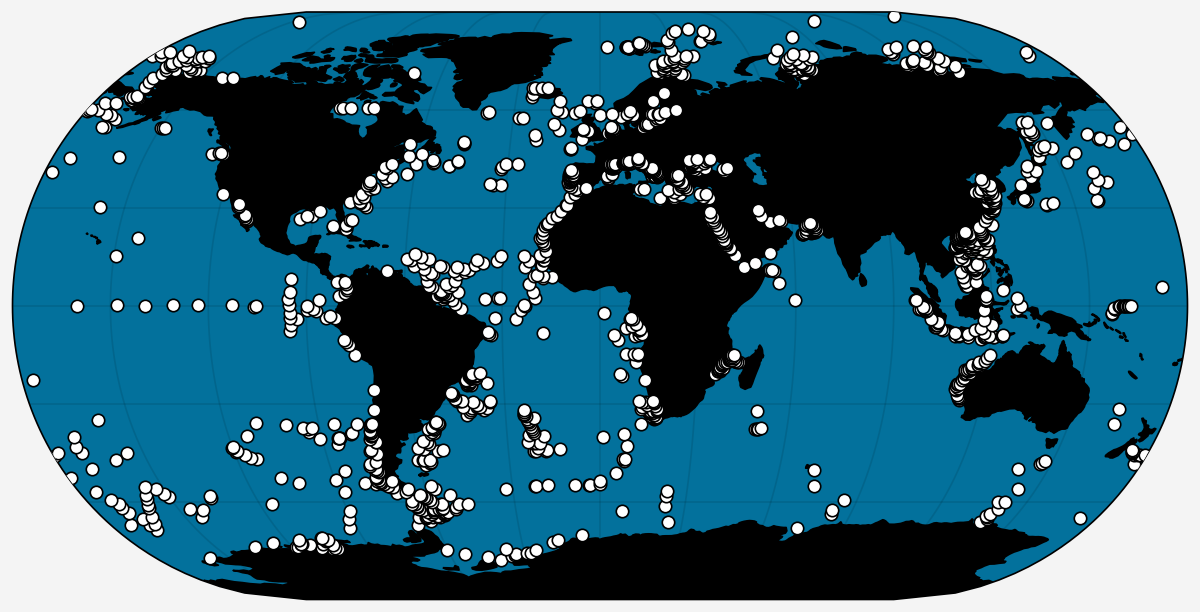

In [23]:
fig, ax = plot.subplots(width=6,proj='eck3',
                        # proj_kw={'lon_0':-150}
                        )
ax.format(
    land=True,landzorder=0,
    facecolor='ocean blue',
    # landcolor='gray7',
    coast=True,coastzorder=1,
    lonlines=30,
    latlines=30,
    # lonlabels='b',
    # latlabels='l',
    # title='Coretop locations',
)

plot_lat = coretop_df['match_lat_04deg']
plot_lon = coretop_df['match_lon_04deg']
ax.scatter(plot_lon, plot_lat, s=20, color='w', mec='k', facecolor='none', zorder=5)
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'coretop_locations_woa23_t00_04degC.pdf'),dpi=300,
            transparent=True)

# Posterior plots --- QC

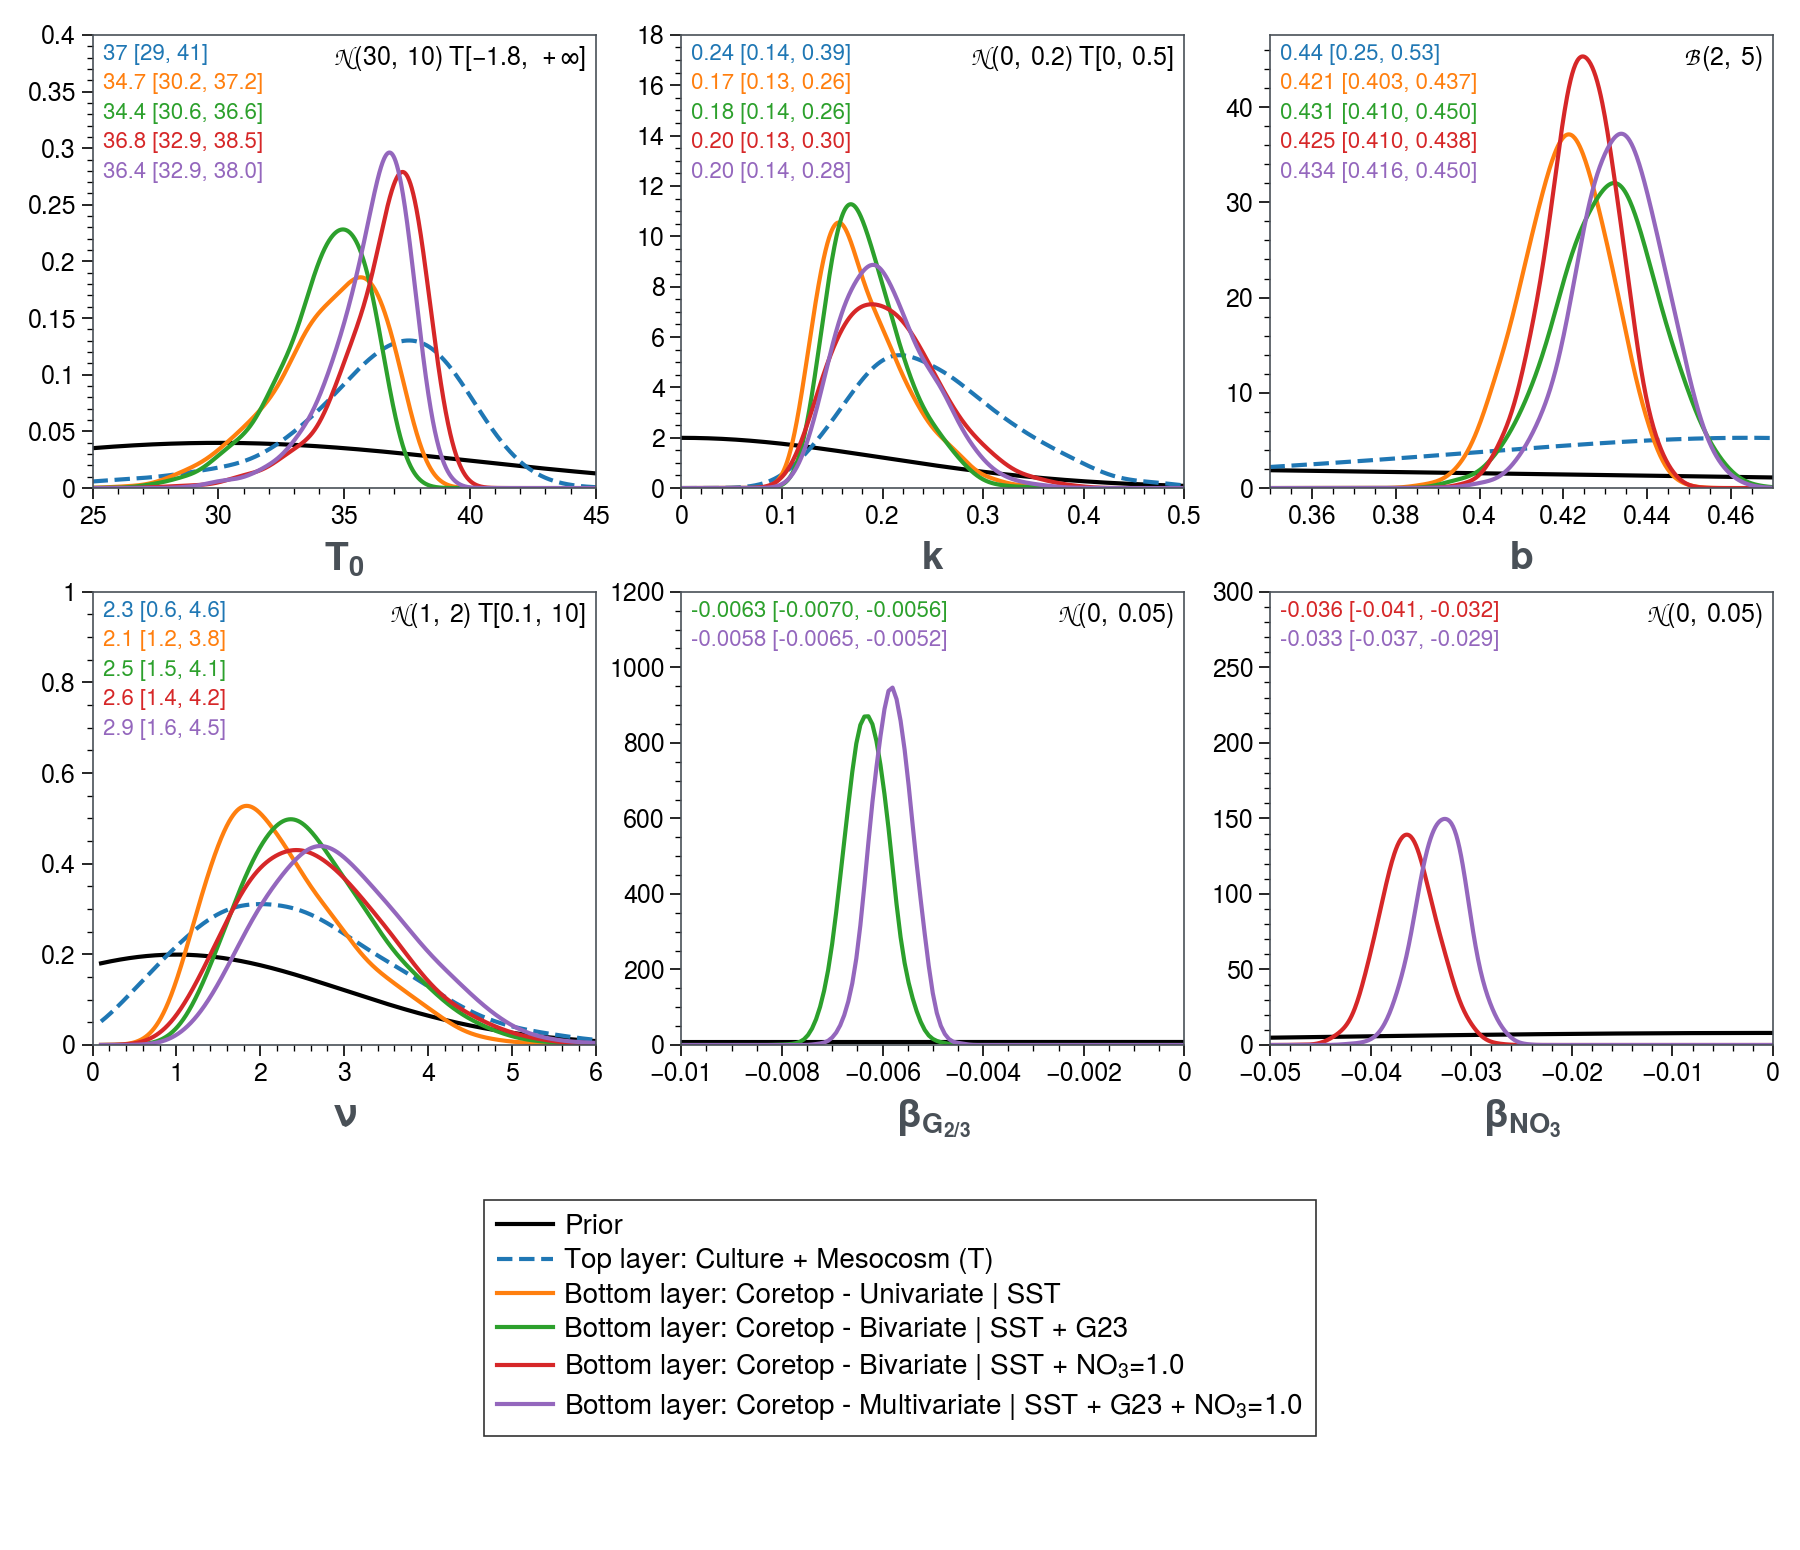

In [57]:
legend_labels = ['Top layer: Culture + Mesocosm (T)', 
                 'Bottom layer: Coretop - Univariate | SST', 
                 'Bottom layer: Coretop - Bivariate | SST + G23', 
                 r'Bottom layer: Coretop - Bivariate | SST + NO$_3$=1.0', 
                #  r'Bottom layer: Coretop - Bivariate | SST + NO$_3$=1.8',
                 r'Bottom layer: Coretop - Multivariate | SST + G23 + NO$_3$=1.0',
                #  r'Bottom layer: Coretop - Multivariate | SST + G23 + NO$_3$=1.8',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────                                                                                                                 
post_fwd_032326 = [                                                                                                                                                                              
    # Stage 1 — culmeso                                                                                                                                                                          
    "gen_logi_fixed_culmeso_cultureT_scaledRI_032326",                                                                                                                                                                                                                                                                                                                           
    # Stage 2 — SST / scaledRI                                                                                                                                                                   
    "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3_032326",                                                                                                                           
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_scaledRI_cren3_032326",
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_no3_1.0_scaledRI_cren3_032326",
    # "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_no3_1.8_scaledRI_cren3_032326",
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_032326",
    # "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_scaledRI_cren3_032326",                                                                                                          
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd_032326,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=True,
    show_prior_expression=True,
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,0.4)
axs[0,1].set_xlim(0,0.5)
axs[0,1].set_ylim(0,18)
axs[0,2].set_xlim(0.35,0.47)
axs[1,0].set_xlim(0,6)
axs[1,0].set_ylim(0,1)
axs[1,1].set_xlim(-0.01,0)
axs[1,1].set_ylim(0,1200)
axs[1,2].set_xlim(-0.05,0)
axs[1,2].set_ylim(0,300)

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color='gray7', fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color='gray7', fontweight='bold')
    
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, color='gray7')
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, color='gray7')
    
    ax.spines[:].set_color('gray7')
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixB_SST_prior_distributions.pdf'),dpi=300)

In [68]:
test_ds_full = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_032326")
test_ds_full_RI04 = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.0_scaledRI_032326")
test_ds_TG23 = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_scaledRI_cren3_032326")
test_ds_TNO3 = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_no3_1.0_scaledRI_cren3_032326")
test_ds_univ_crtp = load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3_032326")
test_ds_univ_crtp_RI04 = load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_032326")

In [69]:
test_ds_univ_crtp

<xarray.Dataset>
Dimensions:              (chain: 4, draw: 1000)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_crtp              (chain, draw) float64 34.07 33.93 31.93 ... 35.82 36.98
    k_crtp               (chain, draw) float64 0.1529 0.1528 ... 0.2032 0.1838
    b_crtp               (chain, draw) float64 0.4158 0.4194 ... 0.4019 0.4026
    v_crtp               (chain, draw) float64 1.91 1.869 1.505 ... 2.835 2.782
    sigma_proxyObs_crtp  (chain, draw) float64 0.05762 0.05753 ... 0.05817
    inflection_point     (chain, draw) float64 38.3 38.02 34.68 ... 40.95 42.55
    R2_full              (chain, draw) float64 0.7458 0.7459 ... 0.744 0.7447
    bayesR2_full         (chain, draw) float64 0.7496 0.7482 ... 0.7612 0.7357
    RMSE_full            (chain, draw) float64 0.05765 0.05765 ... 0.05778
Attributes: (12/32)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_univ_priorApprox_m...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_univ_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       689.6
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS
    filename:                     gen_logi_fixed_hier_crtp_univ_priorApprox_S...

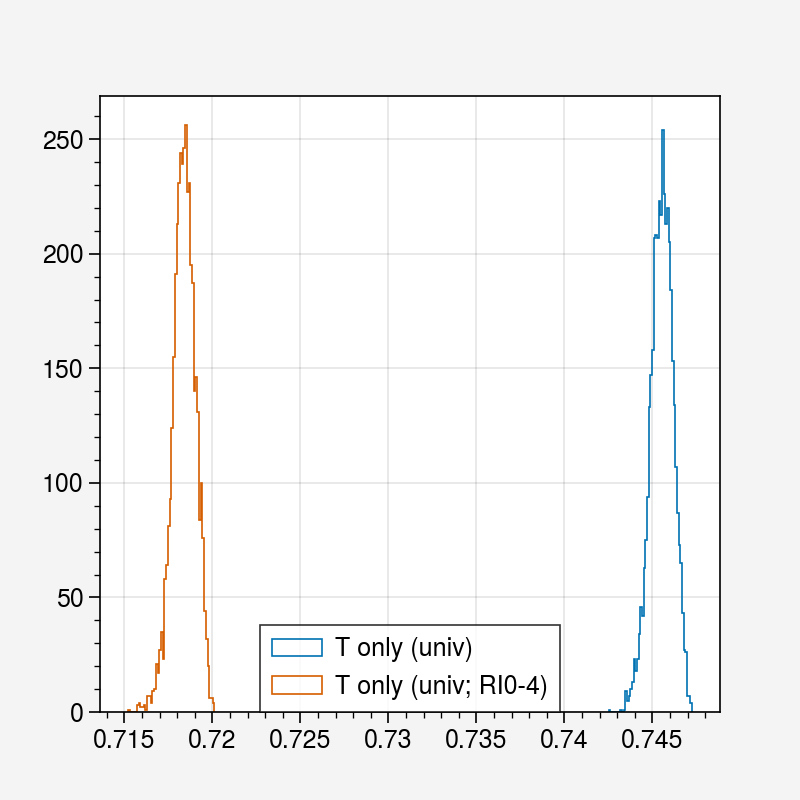

In [74]:
plt.hist(test_ds_univ_crtp['R2_full'].values.flatten(),
         bins=50,label='T only (univ)',histtype='step')
plt.hist(test_ds_univ_crtp_RI04['R2_full'].values.flatten(),
         bins=50,label='T only (univ; RI0-4)',histtype='step')
# plt.hist(test_ds_TG23['R2_full'].values.flatten(),
#          bins=50,label='T + G23',histtype='step')
# plt.hist(test_ds_TNO3['R2_full'].values.flatten(),
# #          bins=50,label='T + NO3',histtype='step')
# plt.hist(test_ds_full['R2_full'].values.flatten(),
#          bins=50,label='T + G23 + NO3',histtype='step')
# plt.hist(test_ds_full_RI04['R2_full'].values.flatten(),
#          bins=50,label='T + G23 + NO3 (RI04)',histtype='step')

plt.legend()



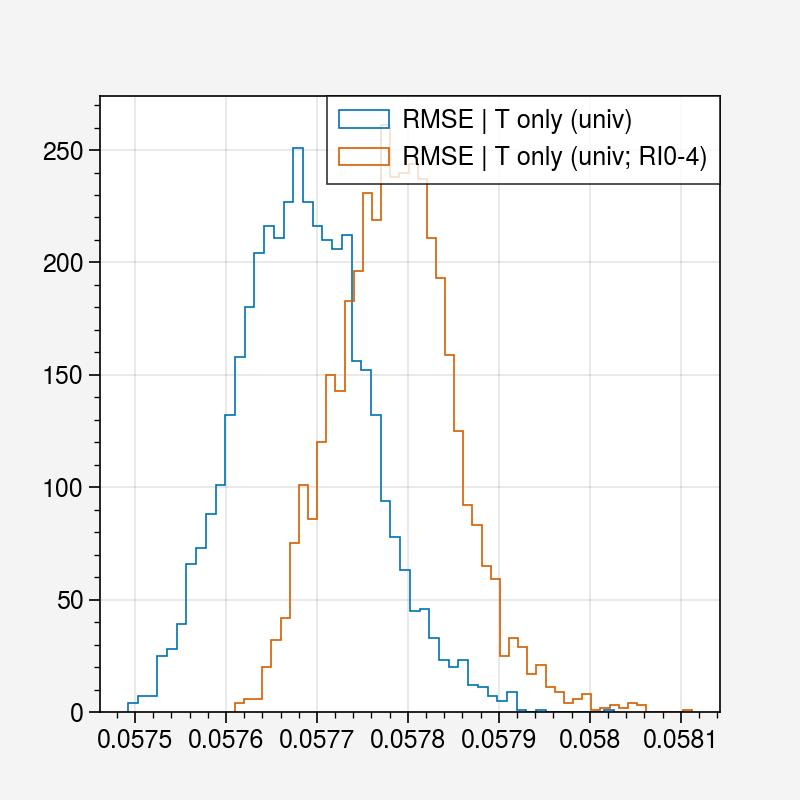

In [73]:
plt.hist(test_ds_univ_crtp['RMSE_full'].values.flatten(),
         bins=50,label='RMSE | T only (univ)',histtype='step')
plt.hist(test_ds_univ_crtp_RI04['RMSE_full'].values.flatten(),
         bins=50,label='RMSE | T only (univ; RI0-4)',histtype='step')
# plt.hist(test_ds_TG23['RMSE_full'].values.flatten(),
#          bins=50,label='RMSE | T + G23',histtype='step')
# plt.hist(test_ds_TNO3['RMSE_full'].values.flatten(),
#          bins=50,label='RMSE | T + NO3',histtype='step')
# plt.hist(test_ds_full['RMSE_full'].values.flatten(),
#          bins=50,label='RMSE | T + G23 + NO3',histtype='step')
# plt.hist(test_ds_full_RI04['RMSE_full'].values.flatten(),
#          bins=50,label='RMSE | T + G23 + NO3 (RI04)',histtype='step')

plt.legend()



In [55]:
def variance_partitioning(ds_T, ds_TG23, ds_TNO3, ds_full, proxyObs,
                        var="sigma_proxyObs_crtp"):                                                                                                                        
    """
    Two-predictor (G23, NO3) variance partitioning of proxy observations.                                                                                                    
                                            
    Columns                                                                                                                                                                  
    -------     
    σ²          : posterior mean of σ²                                                                                                                                       
    % σ²_T      : fraction of non-thermal residual variance
    % total     : fraction of total proxy variance (Var(proxyObs))                                                                                                           
    """                                     
    def sigma2(ds):                                                                                                                                                          
        return float(np.mean(ds[var].values.ravel() ** 2))
                                                                                                                                                                            
    s2 = {                                  
        "T":         sigma2(ds_T),                                                                                                                                           
        "T+G23":     sigma2(ds_TG23),
        "T+NO3":     sigma2(ds_TNO3),                                                                                                                                        
        "T+G23+NO3": sigma2(ds_full),
    }                                                                                                                                                                        
                                        
    obs       = proxyObs.values if hasattr(proxyObs, "values") else np.asarray(proxyObs)
    var_total = float(np.var(obs))                                                                                                                                           
                                            
    thermal = var_total - s2["T"]            # variance explained by T                                                                                                       
    a       = s2["T+NO3"]  - s2["T+G23+NO3"]                         # G23 unique
    b       = s2["T"] - s2["T+G23"] - s2["T+NO3"] + s2["T+G23+NO3"] # shared                                                                                                 
    c       = s2["T+G23"]  - s2["T+G23+NO3"]                         # NO3 unique                                                                                            
    d       = s2["T+G23+NO3"]                                         # residual                                                                                             
                                                                                                                                                                            
    base = s2["T"]                                                                                                                                                           
                                                                                                                                                                            
    rows = [                                                                                                                                                                 
        ("Total proxy variance",    var_total, None,        var_total / var_total * 100),                                                                                    
        (None,),                            
        ("Thermal (T)",             thermal,   thermal / base * 100, thermal / var_total * 100),
        ("G23 unique  [a]",         a,         a / base * 100,       a / var_total * 100),
        ("Shared G23∩NO3  [b]",     b,         b / base * 100,       b / var_total * 100),                                                                                   
        ("NO3 unique  [c]",         c,         c / base * 100,       c / var_total * 100),                                                                                   
        ("Residual  [d]",           d,         d / base * 100,       d / var_total * 100),                                                                                   
        (None,),                                                                                                                                                             
        ("Sum",                     var_total, None,        100.0),                                                                                                          
    ]                                       
                                                                                                                                                                            
    hdr = f"{'Component':>20}  {'σ²':>8}  {'% σ²_T':>8}  {'% total':>8}"
    print(f"\n{hdr}")                                                                                                                                                        
    print("─" * len(hdr))
    for row in rows:                                                                                                                                                         
        if row[0] is None:
            print()                                                                                                                                                          
            continue
        label, val, pct_T, pct_tot = row
        p_T   = f"{pct_T:7.1f}%" if pct_T  is not None else " " * 8
        p_tot = f"{pct_tot:7.1f}%"          
        print(f"{label:>20}  {val:8.5f}  {p_T}  {p_tot}")
        
    return base, var_total, thermal, a, b, c, d
                                                                                                                                                                        
# Usage                                                                                                                                                                      
base, var_total, thermal, a, b, c, d = variance_partitioning(                                                                                                                                                       
test_ds_univ_crtp, test_ds_TG23, test_ds_TNO3, test_ds_full,                                                                                                             
proxyObs=coretop_df["scaledRI_cren3"],                                                                                                                                      
)        


           Component        σ²    % σ²_T   % total
──────────────────────────────────────────────────
Total proxy variance   0.01308              100.0%

         Thermal (T)   0.00974    292.1%     74.5%
     G23 unique  [a]   0.00037     11.1%      2.8%
 Shared G23∩NO3  [b]   0.00006      1.7%      0.4%
     NO3 unique  [c]   0.00029      8.7%      2.2%
       Residual  [d]   0.00262     78.5%     20.0%

                 Sum   0.01308              100.0%


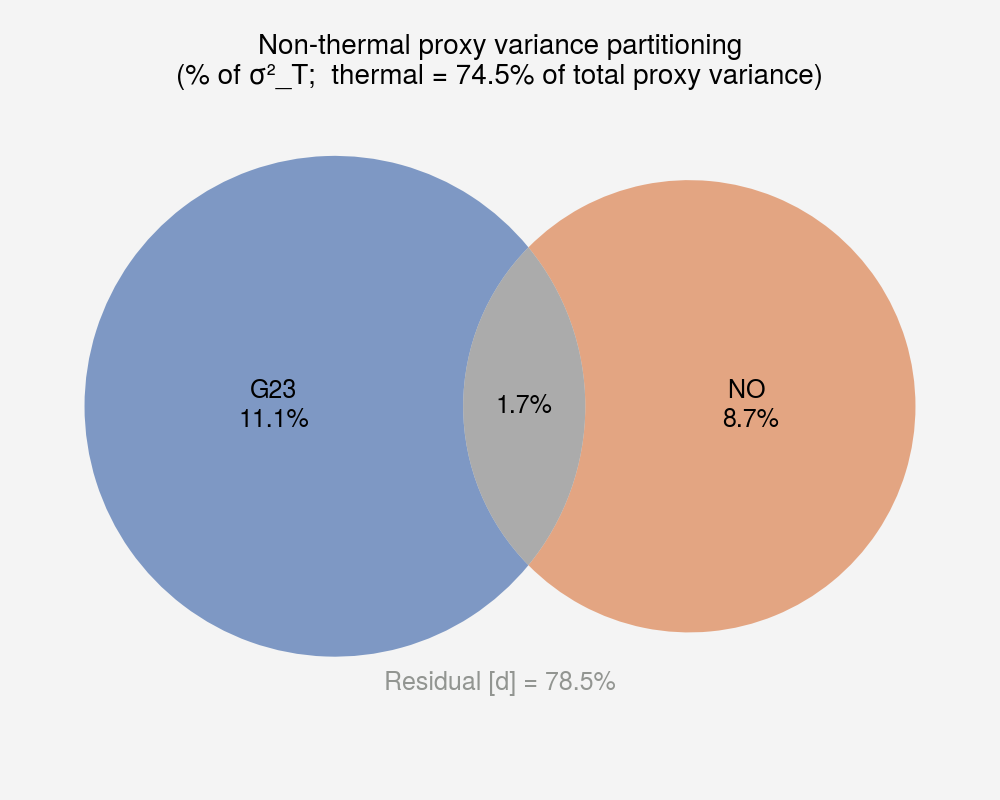

In [56]:
from matplotlib_venn import venn2, venn2_circles                                                                                                                             
import matplotlib.pyplot as plt                                                                                                                                              
                                                                                                                                                                            
fig, ax = plt.subplots(figsize=(5, 4))                                                                                                                                       
                                                                                                                                                                            
# % of σ²_T (non-thermal residual)                                                                                                                                           
a_pct = a / base * 100   # G23 unique                                                                                                                                        
b_pct = b / base * 100   # shared                                                                                                                                            
c_pct = c / base * 100   # NO3 unique                                                                                                                                        
d_pct = d / base * 100   # residual                                                                                                                                          
                                                                                                                                                                            
# venn2 subsets = (G23-only, NO3-only, shared)                                                                                                                               
v = venn2(subsets=(a_pct, c_pct, b_pct), set_labels=("", ""), ax=ax)                                                                                                         
                                                                                                                                                                            
# Colours
v.get_patch_by_id("10").set(facecolor="#4C72B0", alpha=0.7)  # G23                                                                                                           
v.get_patch_by_id("01").set(facecolor="#DD8452", alpha=0.7)  # NO3                                                                                                           
v.get_patch_by_id("11").set(facecolor="#8C8C8C", alpha=0.7)  # shared                                                                                                        
                                                                                                                                                                            
# Region labels                                                                                                                                                              
v.get_label_by_id("10").set_text(f"G23\n{a_pct:.1f}%")                                                                                                                       
v.get_label_by_id("01").set_text(f"NO₃\n{c_pct:.1f}%")
v.get_label_by_id("11").set_text(f"{b_pct:.1f}%")                                                                                                                            

# Residual outside the circles                                                                                                                                               
ax.text(0.5, 0.04, f"Residual [d] = {d_pct:.1f}%",
        ha="center", transform=ax.transAxes, fontsize=9, color="gray")                                                                                                       
                
ax.set_title(                                                                                                                                                                
    "Non-thermal proxy variance partitioning\n"
    f"(% of σ²_T;  thermal = {thermal/var_total*100:.1f}% of total proxy variance)",                                                                                         
    fontsize=10,                                                                                                                                                             
)                                                                                                                                                                            
                                                                                                                                                                            
plt.tight_layout()
plt.savefig("variance_partition_venn.png", dpi=150, bbox_inches="tight")
plt.show()    

In [40]:
for label, ds, var in [                                                                                                                                                      
    ("G23", test_ds_full, "beta_G23_crtp"),                                                                                                                                  
    ("NO3", test_ds_full, "beta_NO3_crtp"),                                                                                                                                  
]:
    draws = ds[var].values.ravel()                                                                                                                                           
    print(f"β_{label}: {np.mean(draws):.4f} ± {np.std(draws):.4f}  "
        f"68% CI [{np.percentile(draws, 16):.4f}, {np.percentile(draws, 84):.4f}]")    

β_G23: -0.0058 ± 0.0004  68% CI [-0.0062, -0.0054]
β_NO3: -0.0329 ± 0.0025  68% CI [-0.0353, -0.0305]


In [ ]:
legend_labels = ['Top layer: Culture + Mesocosm (T)', 
                 'Bottom layer: Coretop - Univariate | Thermo-T', 
                 'Bottom layer: Coretop - Bivariate | Thermo-T + G23', 
                 r'Bottom layer: Coretop - Bivariate | Thermo-T + NO$_3$',
                 r'Bottom layer: Coretop - Multivariate | Thermo-T + G23 + NO$_3$',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────                                                                                                                 
post_fwd_032326 = [                                                                                                                                                                              
    # Stage 1 — culmeso                                                                                                                                                                          
    "gen_logi_fixed_culmeso_cultureT_scaledRI_032326",                                                                                                                                                                                                                                                                                                                           
    # Stage 2 — SST / scaledRI                                                                                                                                                                   
    "gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_scaledRI_cren3_032326",                                                                                                                           
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_scaledRI_cren3_032326",                                                                                                                 
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_no3_1.9_scaledRI_cren3_032326",                                                                                                                     
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.9_scaledRI_cren3_032326",                                                                                                          
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd_032326,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=True,
    show_prior_expression=True,
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,0.8)
axs[0,1].set_xlim(0,0.5)
axs[0,1].set_ylim(0,13)
axs[0,2].set_xlim(0.35,0.47)
axs[1,0].set_xlim(0,6)
axs[1,0].set_ylim(0,1)
axs[1,1].set_xlim(-0.01,0)
axs[1,1].set_ylim(0,1200)
axs[1,2].set_xlim(-0.05,0)
axs[1,2].set_ylim(0,300)

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color='gray7', fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color='gray7', fontweight='bold')
    
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, color='gray7')
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, color='gray7')
    
    ax.spines[:].set_color('gray7')
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixC_thermoT_prior_distributions.pdf'),dpi=300)

In [ ]:
plot_culmeso_df = gridded_combined_df[gridded_combined_df['datatype'].isin(['culture','mesocosm'])].dropna(subset=['scaledRI','SST']).reset_index(drop=True)

y_params = ['scaledRI','scaledRI_cren3']
for y_param in y_params:
    pred_scaledRI_culmeso_results = generate_ensemble_auto(
        post_ds = load_posterior(f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"),
        x_vals = plot_culmeso_df['SST'].values,
        percentiles=[2.5,50,97.5],
    )
    plot_culmeso_df[f'pred_{y_param}'] = pred_scaledRI_culmeso_results['p50']

In [ ]:
y_params = ['scaledRI','scaledRI_cren3']
plot_coretop_df = coretop_df
for y_param in y_params:
    pred_scaledRI_crtp_results = generate_ensemble_auto(
        post_ds = load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_{y_param}_032326"),
        x_vals = plot_coretop_df['SST'].values,
        gdgt23ratio = plot_coretop_df['gdgt23ratio'].values,
        no3 = plot_coretop_df['no3_sf2tc_avg'].values,
        no3_cutoff = 1.8,
        percentiles=[2.5,50,97.5],
    )
    plot_coretop_df[f'pred_{y_param}'] = pred_scaledRI_crtp_results['p50']
    plot_coretop_df[f'residual_{y_param}'] = plot_coretop_df['scaledRI'] - plot_coretop_df[f'pred_{y_param}']


In [ ]:
plot_culmeso_df

In [ ]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_culmeso_df
XX = np.linspace(-2,50,200)
x_param = 'SST'
y_param = 'scaledRI_cren3'
grouped = plot_data.groupby('datatype')
for name, group in grouped:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,
               c=datatype_color_dict.get(name),
               m='o',mec='k',mew=0.5)
    
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,
               c=datatype_color_dict.get(name),
               m='o',mec='k',mew=0.5)
    
    ### linear regression line for each datatype with 95% CI shading
    from sklearn.linear_model import LinearRegression
    from sklearn.utils import resample
    
    model = LinearRegression()
    X = group[x_param].values.reshape(-1, 1)
    y = group[y_param].values
    model.fit(X, y)
    x_range = XX.reshape(-1, 1)
    y_pred = model.predict(x_range)
    axs[0,0].plot(x_range, y_pred, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    slope = model.coef_[0]
    axs[1,0].axhline(slope, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    text = f"{slope:.3f}"
    
    y_adjust = 0.006 if name=='culture' else 0
    axs[1,0].text(1.01, slope + y_adjust, 
                  text,
                  transform=axs[1,0].get_yaxis_transform(),
                  ha = 'left', verticalalignment='center',
                  fontsize=10,fontweight='bold',
                  color=datatype_color_dict.get(name))
    
    
model = LinearRegression()
X = plot_data[x_param].values.reshape(-1, 1)
y = plot_data[y_param].values
model.fit(X, y)
x_range = XX.reshape(-1, 1)
y_pred = model.predict(x_range)
axs[0,0].plot(x_range, y_pred, color='gray9', lw=1, zorder=0)

slope = model.coef_[0]
text = f"{slope:.3f}"
axs[1,0].axhline(slope, color='gray9', lw=1, zorder=0)
axs[1,0].text(1.01, slope + 0.002, text,
            transform=axs[1,0].get_yaxis_transform(),
            ha = 'left', verticalalignment='center',
            fontsize=10,fontweight='bold',
            color='gray9')

# Get all samples
gen_logi_fixed_cul_meso_post_ds = load_posterior(f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326")
t0_samples = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].values.flatten()
b_samples = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].values.flatten()
k_samples = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].values.flatten()
v_samples = gen_logi_fixed_cul_meso_post_ds["v_culmeso"].values.flatten()

# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5',zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)


################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

r_squared_culmeso = r2_score(
    plot_data[y_param],
    plot_data[f'pred_{y_param}']
)
https://easystats.github.io/performance/reference/r2_bayes.html
rmse_culmeso = mean_squared_error(
    plot_data[y_param],
    plot_data[f'pred_{y_param}']
)

print(_fmt_r2(r_squared_culmeso))
text = f'$R^2$ = {_fmt_r2(r_squared_culmeso)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_culmeso))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_culmeso': r'$T_{0,culmeso}$',
    'k_culmeso': r'$k_{culmeso}$',
    'b_culmeso': r'$b_{culmeso}$',
    'v_culmeso': r'$\nu_{culmeso}$',
}
### Posterior sec
var_list = [var_name for var_name in gen_logi_fixed_cul_meso_post_ds.data_vars if (('culmeso' in var_name) & ~('sigma_' in var_name))]
for var in var_list:
    var_samples = gen_logi_fixed_cul_meso_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={var_mean:.4f}, sd={var_sd:.4f}")
    print(_format_stat(var_mean,var_sd))
    text = f"{param_label_dict.get(var,var)} = {_format_stat(var_mean,var_sd)}"
    ax.text(0.98, 0.18 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--')
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Culture and Mesocosm Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')

h, l = axs[0,0].get_legend_handles_labels()
axs[0,0].legend([h[ii] for ii in [1,2]], ['Culture','Mesocosm'], 
                ncol=1,
                fontsize=10, loc='lower right')


###########
plot.rc['abc']=True
axs[:3].format(grid=False,
           abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
           fontsize=12,labelsize=12,
           labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
           xticklabelcolor='gray7',yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold', )

axs[0,0].format(ylim=(0.2,1))
axs[1,1].axis('off')
plot.rc['abc']=False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig6_scaledRI_culmeso_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

In [ ]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_coretop_df
XX = np.linspace(-2,50,200)
grouped = gridded_combined_df.groupby('datatype')

x_param = 'SST'
x_param_fwd = 'thermoT' if x_param == 't_sf2tc_avg' else x_param
y_param = 'scaledRI_cren3'
no3_threshold = 1.9 if ((y_param == 'scaledRI_cren3') & (x_param == 't_sf2tc_avg')) else 1.8
for name, group in grouped:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name),
            alpha=0.5 if name!='coretop' else 1,
            label=name.capitalize())
    
grouped = plot_data.groupby('datatype')
for name, group in grouped: 
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name))
   

sel_post_ds = load_posterior(
        f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{x_param_fwd}_gdgt23ratio_no3_{no3_threshold}_{y_param}_032326' 
)
# Get all samples
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples = sel_post_ds["b_crtp"].values.flatten()
k_samples = sel_post_ds["k_crtp"].values.flatten()
v_samples = sel_post_ds["v_crtp"].values.flatten()
beta_gdgt23ratio_samples = sel_post_ds["beta_G23_crtp"].values.flatten()
beta_no3_samples = sel_post_ds["beta_NO3_crtp"].values.flatten()
# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

### median curve corrected for median beta_gdgt23ratio and beta_no3 values
median_beta_gdgt23ratio = np.median(beta_gdgt23ratio_samples)
median_beta_no3 = np.median(beta_no3_samples)

median_curve_23_corrected = median_curve + median_beta_gdgt23ratio * 15
median_curve_no3_corrected = median_curve + median_beta_no3 * np.log10(0.01)

axs[0,0].plot(XX, median_curve_23_corrected, 'k--', lw=1, label='Median + G23 = 15', zorder=1)
axs[0,0].plot(XX, median_curve_no3_corrected, 'k-.', lw=1, label=r'Median + NO$_{3}^{-}$ = 0.01', zorder=1)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

nonnan_idx = ~plot_data[y_param].isna() & ~plot_data[f'pred_{y_param}'].isna()
r_squared_crtp = r2_score(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)

rmse_crtp = mean_squared_error(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)
text = f'$R^2$ = {_fmt_r2(r_squared_crtp)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_crtp))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_crtp': r'$T_{0}$',
    'k_crtp': r'$k$',
    'b_crtp': r'$b$',
    'v_crtp': r'$\nu$',
    'beta_G23_crtp': r'$\beta_{G_{2/3}}$',
    'beta_NO3_crtp': r'$\beta_{NO_{3}}$',
    
}
### Posterior sec
var_list = [var_name for var_name in sel_post_ds.data_vars if (('crtp' in var_name) & ~('sigma_' in var_name))]
for var in var_list:
    var_samples = sel_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={_format_stat(var_mean,var_sd)}")
    fmtted_text = _format_stat(var_mean,var_sd,fmt='.2g') if var == 'beta_G23_crtp' else _format_stat(var_mean,var_sd)
    text = f"{param_label_dict.get(var,var)} = {fmtted_text}"
    ax.text(0.98, 0.26 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--',zorder=0)
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Coretop Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')


h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend(h[0:3][::-1]+h[3:],
                ['Median calibration curve','Median + NO$_{3}^{-}$ = 0.01','Median + G23 = 15',]+l[3:], 
                ncol=1,
                fontsize=10, loc='lower right')

################################################################
# Panel (d): Inverse uncertainty
################################################################
ax = axs[1,1]
ax.axis('on')  # Turn axis back on

# Calculate inverse derivatives for all posterior samples
all_inv_slopes = 1 / all_slopes  # dT/dRI = 1/(dRI/dT)

# Propagate RI measurement uncertainty to temperature uncertainty
sigma_RI = 0.03  # Assumed RI analytical uncertainty to be similar to TEX86
all_T_uncertainty = sigma_RI * np.abs(all_inv_slopes)

# Calculate median and CI
median_T_uncertainty = np.median(all_T_uncertainty, axis=0)
ci_low = np.percentile(all_T_uncertainty, 16, axis=0)
ci_high = np.percentile(all_T_uncertainty, 84, axis=0)

# Plot uncertainty vs temperature
ax.fill_between(XX, ci_low, ci_high, alpha=0.2, color='gray')
ax.plot(XX, median_T_uncertainty, c='k', lw=2, label='Median uncertainty')

# Add reference lines
# ax.axhline(3, ls='-', color='gray7', lw=0.2)
ax.axhline(5, ls='-', color='gray7', lw=0.2)

# Add text labels for reference lines
ax.text(1.01, 5, '±5°C', transform=ax.get_yaxis_transform(),
        ha='left', va='center', fontsize=9, color='gray5')

# Find where uncertainty crosses 5°C threshold
threshold = 5.0
# Find crossings (where curve goes above/below threshold)
above_threshold = median_T_uncertainty > threshold
# Find indices where it transitions
crossings = np.where(np.diff(above_threshold.astype(int)))[0]

if len(crossings) >= 2:
    # Low temperature crossing (left side)
    low_T_idx = crossings[0]
    low_T_cross = XX[low_T_idx]
    low_T_unc = median_T_uncertainty[low_T_idx]
    
    # High temperature crossing (right side)  
    high_T_idx = crossings[-1]
    high_T_cross = XX[high_T_idx]
    high_T_unc = median_T_uncertainty[high_T_idx]
    
    # Draw vertical lines at crossings
    
    ax.axvline(low_T_cross, color='gray7', ls='-', lw=0.2)
    ax.axvline(high_T_cross, color='gray7', ls='-', lw=0.2)

    
    # Optional: shade regions with >5°C uncertainty
    ax.axvspan(XX[0], low_T_cross, alpha=0.1, color='gray', zorder=0)
    ax.axvspan(high_T_cross, XX[-1], alpha=0.1, color='gray', zorder=0)

# Format
ax.format(
    xlim=(-2, 50),
    ylim=(0, 15),  # Adjust based on your data
    xlabel='Temperature (°C)',
    ylabel='T uncertainty (°C)',
)

# Add title
text = 'Temperature Prediction Uncertainty'
ax.text(0.08, 0.9, text, transform=ax.transAxes,
        fontsize=14, va='top', ha = 'left',
        fontweight='bold', color='gray7')

# Add note about sigma_RI assumption and precision window
text = f'based on ±{sigma_RI:.2f} Scaled RI'
ax.text(0.08, 0.65, text, transform=ax.transAxes,
        fontsize=9, ha='left', va='bottom', color='gray7')

# text = f'{low_T_cross:.1f}–{high_T_cross:.1f}°C'

if len(crossings) >= 2:
    text = f'{low_T_cross:.1f}°C'
    ax.text(low_T_cross+1, 5.1, text, 
            ha='left', va='bottom', fontsize=10, 
            fontweight='bold', color='gray7')
    text = f'{high_T_cross:.1f}°C'
    ax.text(high_T_cross-1, 5.1, text, 
            ha='right', va='bottom', fontsize=10,
            fontweight='bold', color='gray7')


###########
# Update this line (around line where you currently format axs[:3])
axs.format(grid=False,
           abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
           fontsize=12, labelsize=12,
           labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
           xticklabelcolor='gray7', yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold')
axs[0,0].format(ylim=(0.2,1))
axs[1,0].format(ylim=(0,0.035))

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig7_{x_param}_{y_param}_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

In [ ]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_coretop_df
XX = np.linspace(-2,50,200)
grouped = gridded_combined_df.groupby('datatype')

x_param = 't_sf2tc_avg'
x_param_fwd = 'thermoT' if x_param == 't_sf2tc_avg' else x_param
y_param = 'scaledRI_cren3'
no3_threshold = 1.9 if ((y_param == 'scaledRI_cren3') & (x_param == 't_sf2tc_avg')) else 1.8
for name, group in grouped:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=20,
            mec='k', lw=0.5,
            c=datatype_color_dict.get(name),
            alpha=0.5 if name!='coretop' else 1,
            label=name.capitalize())
    
grouped = plot_data.groupby('datatype')
for name, group in grouped: 
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=20,
            mec='k', lw=0.5, c=datatype_color_dict.get(name))
   

sel_post_ds = load_posterior(
        f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{x_param_fwd}_gdgt23ratio_no3_{no3_threshold}_{y_param}_032326' 
)
# Get all samples
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples = sel_post_ds["b_crtp"].values.flatten()
k_samples = sel_post_ds["k_crtp"].values.flatten()
v_samples = sel_post_ds["v_crtp"].values.flatten()
beta_gdgt23ratio_samples = sel_post_ds["beta_G23_crtp"].values.flatten()
beta_no3_samples = sel_post_ds["beta_NO3_crtp"].values.flatten()
# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

### median curve corrected for median beta_gdgt23ratio and beta_no3 values
median_beta_gdgt23ratio = np.median(beta_gdgt23ratio_samples)
median_beta_no3 = np.median(beta_no3_samples)

median_curve_23_corrected = median_curve + median_beta_gdgt23ratio * 15
median_curve_no3_corrected = median_curve + median_beta_no3 * np.log10(0.01)

axs[0,0].plot(XX, median_curve_23_corrected, 'k--', lw=1, label='Median + G23 = 15', zorder=1)
axs[0,0].plot(XX, median_curve_no3_corrected, 'k-.', lw=1, label=r'Median + NO$_{3}^{-}$ = 0.01', zorder=1)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

nonnan_idx = ~plot_data[y_param].isna() & ~plot_data[f'pred_{y_param}'].isna()
r_squared_crtp = r2_score(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)

rmse_crtp = mean_squared_error(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)
text = f'$R^2$ = {_fmt_r2(r_squared_crtp)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_crtp))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_crtp': r'$T_{0}$',
    'k_crtp': r'$k$',
    'b_crtp': r'$b$',
    'v_crtp': r'$\nu$',
    'beta_G23_crtp': r'$\beta_{G_{2/3}}$',
    'beta_NO3_crtp': r'$\beta_{NO_{3}}$',
    
}
### Posterior sec
var_list = [var_name for var_name in sel_post_ds.data_vars if (('crtp' in var_name) & ~('sigma_' in var_name))]
for var in var_list:
    var_samples = sel_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={_format_stat(var_mean,var_sd)}")
    
    text = f"{param_label_dict.get(var,var)} = {_format_stat(var_mean,var_sd)}"
    ax.text(0.98, 0.26 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--',zorder=0)
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Coretop Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')


h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend(h[0:3][::-1]+h[3:-1],
                ['Median calibration curve','Median + NO$_{3}^{-}$ = 0.01','Median + G23 = 15',]+l[3:-1], 
                ncol=1,
                fontsize=10, loc='lower right')

################################################################
# Panel (d): Inverse uncertainty
################################################################
ax = axs[1,1]
ax.axis('on')  # Turn axis back on

# Calculate inverse derivatives for all posterior samples
all_inv_slopes = 1 / all_slopes  # dT/dRI = 1/(dRI/dT)

# Propagate RI measurement uncertainty to temperature uncertainty
sigma_RI = 0.03  # Assumed RI analytical uncertainty to be similar to TEX86
all_T_uncertainty = sigma_RI * np.abs(all_inv_slopes)

# Calculate median and CI
median_T_uncertainty = np.median(all_T_uncertainty, axis=0)
ci_low = np.percentile(all_T_uncertainty, 16, axis=0)
ci_high = np.percentile(all_T_uncertainty, 84, axis=0)

# Plot uncertainty vs temperature
ax.fill_between(XX, ci_low, ci_high, alpha=0.2, color='gray')
ax.plot(XX, median_T_uncertainty, c='k', lw=2, label='Median uncertainty')

# Add reference lines
# ax.axhline(3, ls='-', color='gray7', lw=0.2)
ax.axhline(5, ls='-', color='gray7', lw=0.2)

# Add text labels for reference lines
ax.text(1.01, 5, '±5°C', transform=ax.get_yaxis_transform(),
        ha='left', va='center', fontsize=9, color='gray5')

# Find where uncertainty crosses 5°C threshold
threshold = 5.0
# Find crossings (where curve goes above/below threshold)
above_threshold = median_T_uncertainty > threshold
# Find indices where it transitions
crossings = np.where(np.diff(above_threshold.astype(int)))[0]

if len(crossings) >= 2:
    # Low temperature crossing (left side)
    low_T_idx = crossings[0]
    low_T_cross = XX[low_T_idx]
    low_T_unc = median_T_uncertainty[low_T_idx]
    
    # High temperature crossing (right side)  
    high_T_idx = crossings[-1]
    high_T_cross = XX[high_T_idx]
    high_T_unc = median_T_uncertainty[high_T_idx]
    
    # Draw vertical lines at crossings
    
    ax.axvline(low_T_cross, color='gray7', ls='-', lw=0.2)
    ax.axvline(high_T_cross, color='gray7', ls='-', lw=0.2)

    
    # Optional: shade regions with >5°C uncertainty
    ax.axvspan(XX[0], low_T_cross, alpha=0.1, color='gray', zorder=0)
    ax.axvspan(high_T_cross, XX[-1], alpha=0.1, color='gray', zorder=0)

# Format
ax.format(
    xlim=(-2, 50),
    ylim=(0, 15),  # Adjust based on your data
    xlabel='Temperature (°C)',
    ylabel='T uncertainty (°C)',
)

# Add title
text = 'Temperature Prediction Uncertainty'
ax.text(0.08, 0.9, text, transform=ax.transAxes,
        fontsize=14, va='top', ha = 'left',
        fontweight='bold', color='gray7')

# Add note about sigma_RI assumption and precision window
text = f'based on ±{sigma_RI:.3f} Scaled RI'
ax.text(0.08, 0.65, text, transform=ax.transAxes,
        fontsize=9, ha='left', va='bottom', color='gray7')

# text = f'{low_T_cross:.1f}–{high_T_cross:.1f}°C'

if len(crossings) >= 2:
    text = f'{low_T_cross:.1f}°C'
    ax.text(low_T_cross+1, 5.1, text, 
            ha='left', va='bottom', fontsize=10, 
            fontweight='bold', color='gray7')
    text = f'{high_T_cross:.1f}°C'
    ax.text(high_T_cross-1, 5.1, text, 
            ha='right', va='bottom', fontsize=10,
            fontweight='bold', color='gray7')


###########
# Update this line (around line where you currently format axs[:3])
axs.format(grid=False,
           abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
           fontsize=12, labelsize=12,
           labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
           xticklabelcolor='gray7', yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold')

axs[1,0].format(ylim=(0,0.035))

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'figSxx_{x_param}_{y_param}_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

In [ ]:
# url = 'https://www.ncei.noaa.gov/pub/data/paleo/contributions_by_author/tierney2015/tierney2015tex86.txt'
# TT15_coretop_df = pd.read_csv(
#     url,
#     sep='\t',
#     comment='#',
#     na_values='-999'
# )
# TT15_coretop_df = TT15_coretop_df.dropna(subset=['tex86','WOA09_SST']).reset_index(drop=True)
# TT15_coretop_df['binned_tex86'] = pd.cut(TT15_coretop_df['tex86'], bins=np.arange(0,1.05,0.05), right=False)


# methods = ['schouten02','kim2010_tex86H','OBrien17']
# for method in methods:
#     TT15_coretop_df[f'predSST_{method}'] = predictSSTfromTEX(
#         input_tex=TT15_coretop_df['tex86'],
#         method_name=method
#     )
    
#     TT15_coretop_df[f'Tres_{method}'] = TT15_coretop_df['WOA09_SST'] - TT15_coretop_df[f'predSST_{method}']
    
# ### predict T from TEX86 with BAYSPAR
# TT15_coretop_df['predSST_bayspar_mean'] = np.nan
# for i in tqdm(range(len(TT15_coretop_df))):
#     try:
#         TT15_coretop_df.loc[i,'predSST_bayspar_mean'] = bsr.predict_seatemp(TT15_coretop_df['tex86'].iloc[i].reshape(1),
#                                                                              lon=TT15_coretop_df['longitude'].iloc[i].reshape(1),
#                                                                              lat=TT15_coretop_df['latitude'].iloc[i].reshape(1),
#                                                                              prior_std=6,temptype='sst').percentile(50)[0]
        
#         TT15_coretop_df.loc[i,'Tres_bayspar'] = TT15_coretop_df['WOA09_SST'].iloc[i] - TT15_coretop_df.loc[i,'predSST_bayspar_mean']
#     except:
#         continue
    
# ### save for reuse
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'TT15_coretop_data.pkl'
# TT15_coretop_df.to_pickle(os.path.join(fpath,fname))

### reload
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'TT15_coretop_data.pkl'
TT15_coretop_df = pd.read_pickle(os.path.join(fpath,fname))
TT15_coretop_df

In [ ]:
methods = ['schouten02','kim2010_tex86H']
features = ['tex86','WOA09_SST']
temp_features = ['predSST_bayspar_mean'] + [f'predSST_{method}' for method in methods] 
predicted_SST_df = TT15_coretop_df[TT15_coretop_df['latitude']<70][features+temp_features].copy()
predicted_SST_df['t_est_range'] = predicted_SST_df[temp_features].max(axis=1) - predicted_SST_df[temp_features].min(axis=1)
predicted_SST_df = predicted_SST_df.sort_values(by='tex86').reset_index(drop=True)
predicted_SST_df['binned_tex86'] = pd.cut(predicted_SST_df['tex86'], bins=np.arange(-0.025,1.05,0.05), right=False)
predicted_SST_df

In [ ]:
methods = ['schouten02', 'kim2010_tex86H', 'OBrien17']                                                                                             
value_cols = [f'Tres_{m}' for m in methods] + ['Tres_bayspar']                                                                                     
                                                                                                                                                    
binned_t_res_df = (                                                                                                                                
    TT15_coretop_df[TT15_coretop_df['latitude'] < 70]                                                                                              
    .groupby('binned_tex86', observed=True)[value_cols]                                                                                            
    .agg(['min', 'mean', 'max'])
    .reset_index()                                                                                                                                 
)                                                                                                                                                  
binned_t_res_df.columns = ['_'.join(col).strip('_') for col in binned_t_res_df.columns]
binned_t_res_df

In [ ]:
TT15_coretop_df.columns

In [ ]:
binned_t_res_df['binned_tex86']

In [ ]:
binned_tex_t_est_df = (
    predicted_SST_df
    .groupby('binned_tex86', observed=True)['t_est_range']                                                                                         
    .agg(['min', 'max', 'mean'])
    .rename(columns={'min': 't_est_range_min', 'max': 't_est_range_max', 'mean': 't_est_range_mean'})                                              
    .reset_index()                                                                                                                                 
)                                                                                                                                                  
binned_tex_t_est_df['mid_tex_bin'] = binned_tex_t_est_df['binned_tex86'].apply(lambda iv: iv.mid)
binned_tex_t_est_df

In [ ]:
fig, axs = plot.subplots(width=8,ncols=3,wratios=[1,0.5,0.5],sharex=0)

ax = axs[0] 
# grouped = gridded_combined_df.groupby('datatype')
# for name, group in grouped:
#     if name!='coretop':
#         continue
#     else:
#         ax.scatter(group['SST'], group['TEX86'], 
#                 m=datatype_marker_dict.get(name,'o'), 
#                 mec='none' if name=='coretop' else 'black',
#                 label=name,
#                 color=datatype_color_dict.get(name,'gray5'),)

below70N_idx = TT15_coretop_df['latitude']<70
ax.scatter(TT15_coretop_df['WOA09_SST'][below70N_idx], TT15_coretop_df['tex86'][below70N_idx],
           m='.',
           c='gray5')
ax.scatter(TT15_coretop_df['WOA09_SST'][~below70N_idx], TT15_coretop_df['tex86'][~below70N_idx],
           m='o',mec='gray7',
           facecolor='none',
           label='>70°N')

ax.format(
    xlabel=r'SST ($\degree$C)',
    ylabel=r'TEX$_{86}$',
)

#### existing calibration models

temperature_range = np.linspace(-2, 50, 100)
methods = ['schouten02','kim2010_tex86H']
colors = ['red9','yellow9','lime9']
for i, method_name in enumerate(methods):
    predicted_tex = predictTEXfromSST(temperature_range,method_name=method_name)
    ax.plot(temperature_range, predicted_tex,
            c=colors[i],lw=2,
            ls='-',
            label=f'{method_name}',)
    
#### bayspar forward model

mid_redsea_lat = coretop_df[coretop_df['regionName']=='Red Sea']['match_lat_04deg'].median()
mid_redsea_lon = coretop_df[coretop_df['regionName']=='Red Sea']['match_lon_04deg'].median()
min_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].min()-2
max_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].max()+2

xx = np.linspace(min_redsea_sst, max_redsea_sst, 50)
pred_tex_redsea = bsr.predict_tex(
    xx,
    lat=mid_redsea_lat,
    lon=mid_redsea_lon,
    temptype='sst'
).percentile(50)

ax.plot([xx.min(),xx.max()], [pred_tex_redsea.min(),pred_tex_redsea.max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Red Sea',)


min_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].min()-2
max_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].max()+2
xx = np.linspace(min_mediterranean_sst, max_mediterranean_sst, 50)

mid_mediterranean_lat = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lat_04deg'].median()
mid_mediterranean_lon = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lon_04deg'].median()
pred_tex_mediterranean = bsr.predict_tex(
    xx,
    lat=mid_mediterranean_lat,
    lon=mid_mediterranean_lon,
    temptype='sst'
).percentile([10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_mediterranean[:,1].min(),pred_tex_mediterranean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Mediterranean Sea',)

# ax.fill_between([xx.min(),xx.max()], 
#                 [pred_tex_mediterranean[:,0].min(),pred_tex_mediterranean[:,0].max()],
#                 [pred_tex_mediterranean[:,2].min(),pred_tex_mediterranean[:,2].max()],
#                 color='grape9',alpha=0.2)

min_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].min()-2
max_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].max()+2
xx = np.linspace(min_southernocean_sst, max_southernocean_sst, 50)
mid_southernocean_lat = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lat_04deg'].median()
mid_southernocean_lon = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lon_04deg'].median()
pred_tex_southernocean = bsr.predict_tex(
    xx,
    lat=mid_southernocean_lat,
    lon=mid_southernocean_lon,
    temptype='sst'
).percentile([10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_southernocean[:,1].min(),pred_tex_southernocean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Southern Ocean',)

ax.format(
    ylim=(0,1),
    xlim=(-2,50),
    tickminor=False
)

method_list = ['schouten02','kim2010_tex86H']
annonation_dict = {
    "schouten02":{"text": "Linear (Original)","y_top": 0.45,"color": 'red9',
              "source":"Schouten et al. (2002)"},
    "kim2010_tex86H":{"text": "Exponential","y_top": 0.325,"color": 'yellow9',
                "source":"Kim et al. (2010)"},
    "BAYSPAR":{"text": "BAYSPAR","y_top": 0.2,"color": 'grape9',
                "source":"Tierney et al. (2014)"},
}
### Calibration models annotation
for i, method_name in enumerate(methods):
    if method_name in annonation_dict:
        text_str = annonation_dict[method_name]["text"]
        y_top = annonation_dict[method_name]["y_top"]
        color = annonation_dict[method_name]["color"]
        ax.text(0.98,y_top,
                text_str,
                transform=ax.transAxes,
                color=color,
                fontsize=13, fontweight='bold',
                ha='right',
                va='top',
                alpha=0.8
               )
        ax.text(0.98,y_top-0.05,
                annonation_dict[method_name]["source"],
                transform=ax.transAxes,
                color=color,
                fontsize=10,
                ha='right',
                va='top',
                alpha=0.8
               )
### annotation for BAYSPAR
text_str = annonation_dict["BAYSPAR"]["text"]
y_top = annonation_dict["BAYSPAR"]["y_top"]
color = annonation_dict["BAYSPAR"]["color"]
ax.text(0.98,y_top,
        text_str,
        transform=ax.transAxes,
        color=color,
        fontsize=13, fontweight='bold',
        ha='right',
        va='top',
        alpha=0.8
       )
ax.text(0.98,y_top-0.05,
        annonation_dict["BAYSPAR"]["source"],
        transform=ax.transAxes,
        color=color,
        fontsize=10,
        ha='right',
        va='top',
        alpha=0.8
       )
#### boxplot of T residuals
ax = axs[1]
method_list = ['schouten02','kim2010_tex86H','bayspar']
colors = ['red9','yellow9','grape9']
ypos_offset = [-0.01,0,0.01]
for i in range(len(binned_t_res_df)):
    ypos = binned_t_res_df['binned_tex86'].iloc[i].mid
    for j, method_name in enumerate(method_list):
        res_min = binned_t_res_df[f'Tres_{method_name}_min'].iloc[i]
        res_max = binned_t_res_df[f'Tres_{method_name}_max'].iloc[i]
        res_mean = binned_t_res_df[f'Tres_{method_name}_mean'].iloc[i]
        ax.plot([res_min, res_max],
                [ypos+ypos_offset[j], ypos+ypos_offset[j]],
                c=colors[j], lw=2.5, solid_capstyle='butt', alpha=0.7)
        ax.plot(res_mean,
                ypos+ypos_offset[j],
                marker='|', c=colors[j], markersize=5,markeredgewidth=2,zorder=5)

ax.format(
    xlabel=r'Range of T Residuals ($\degree$C)'+'\n(Observed - Predicted)',
    xlim=(-17,17),
)

### boxplot of prediction ranges
ax = axs[2] 
for i in range(len(binned_tex_t_est_df)):
    ypos = binned_tex_t_est_df['mid_tex_bin'].iloc[i]
    ax.plot([binned_tex_t_est_df['t_est_range_min'].iloc[i], binned_tex_t_est_df['t_est_range_max'].iloc[i]],
            [ypos, ypos],
            c='gray5', lw=6, solid_capstyle='butt', alpha=0.7)
    ax.plot(binned_tex_t_est_df['t_est_range_mean'].iloc[i],
            ypos,
            marker='|', c='black', markersize=10,markeredgewidth=2)
    
ax.format(
    xlabel=r'$\Delta$T Range ($\degree$C)',
    ylabel=r'',
    xlim=(0,15),
    ylim=(0,1),
    tickminor=False
)
# h, l = ax.get_legend_handles_labels()
# ax.legend(h[5:], l[5:], loc='ul', ncols=1,frameon=False)
# ax.legend(h[:5], l[:5], loc='lr', ncols=1,frameon=False)




axs.format(abc=True,abcloc='ul',
            abcsize=18,
            abccolor='gray8')

fpath = f'{local_github_path}/figures/manuscript'
fig.savefig(os.path.join(fpath,'existing_calibrations_with_DeltaT_Tres_ranges.pdf'),dpi=300)

# Residuals plot

In [ ]:
import numpy as np
from scipy.stats import gamma
import xarray as xr

def calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25):
    """
    Calculate gamma-weighted subsurface temperature (0-200m).
    
    Parameters:
    -----------
    T_da : xarray.DataArray
        Temperature data with depth dimension
    depth_dim : str
        Name of depth dimension (default: 'depth')
    alpha : float
        Gamma distribution shape parameter (default: 6.5)
    beta : float
        Gamma distribution scale parameter (default: 25 meters)
    
    Returns:
    --------
    subT : xarray.DataArray
        Gamma-weighted subsurface temperature
    """
    
    # Select top 200m
    T_200m = T_da.sel({depth_dim: slice(0, 200)})
    depths = T_200m[depth_dim].values
    
    # Calculate gamma weights
    # Gamma PDF: f(z; α, β) = (z^(α-1) * exp(-z/β)) / (β^α * Γ(α))
    weights = gamma.pdf(depths, a=alpha, scale=beta)
    
    # Normalize weights to sum to 1
    weights_norm = weights / np.sum(weights)
    
    # Create xarray DataArray for weights
    weights_da = xr.DataArray(
        weights_norm,
        coords={depth_dim: depths},
        dims=[depth_dim]
    )
    
    # Calculate weighted average
    subT = (T_200m * weights_da).sum(dim=depth_dim)
    
    return subT

# Usage example:
subT = calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25)

In [ ]:
coretop_df['subT_gamma'] = np.array([
    subT.sel(lon=coretop_df.loc[i,'match_lon_04deg'], lat=coretop_df.loc[i,'match_lat_04deg'], method='nearest').values
    for i in range(len(coretop_df))
])

# Predict proxy values from temperature

In [ ]:
# pred_TEX_BAYSPAR_SST = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     sst = row['SST']
#     if not np.isnan(sst):
#         pred_TEX_BAYSPAR_SST[i] = bsr.predict_tex(
#             np.atleast_1d(sst),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             temptype='sst'
#         ).percentile(50)[0]
        
# display(pred_TEX_BAYSPAR_SST)

# pred_TEX_BAYSPAR_subT = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     sst = row['subT_gamma']
#     if not np.isnan(sst):
#         pred_TEX_BAYSPAR_subT[i] = bsr.predict_tex(
#             np.atleast_1d(sst),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             temptype='subt'
#         ).percentile(50)[0]
        
# pred_TEX_BAYSPAR_subT

# ## Save for reuse
# a = coretop_df[['match_lat_04deg', 'match_lon_04deg']]
# b = pd.DataFrame(pred_TEX_BAYSPAR_SST,columns=['predTEX_bsr_sst'])
# c = pd.DataFrame(pred_TEX_BAYSPAR_subT,columns=['predTEX_bsr_subt'])

# pred_TEX_BAYSPAR_p50_df = pd.concat([a,b,c],axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'predTEX_bayspar_p50.csv'
# pred_TEX_BAYSPAR_p50_df.to_csv(os.path.join(fpath,fname),index=False)

## load result
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'predTEX_bayspar_p50.csv'
pred_TEX_BAYSPAR_p50_df = pd.read_csv(os.path.join(fpath,fname))
pred_TEX_BAYSPAR_SST = pred_TEX_BAYSPAR_p50_df['predTEX_bsr_sst']
pred_TEX_BAYSPAR_subT= pred_TEX_BAYSPAR_p50_df['predTEX_bsr_subt']

In [ ]:
def run_bayesian_variance_partitioning(posterior_names: dict) -> dict:
    """
    Compute sequential R² variance partitioning by loading each separately-fit
    posterior and extracting R2_full / bayesR2_full per draw.

    Each posterior uses its OWN estimated parameters, avoiding the parameter
    confounding that arises from zeroing betas in a single full-model posterior.
    Delta quantities are derived by differencing R2_full across posteriors.

    Parameters
    ----------
    posterior_names : dict
        Keys are model labels, values are posterior name strings for load_posterior().
        Expected keys (in sequential order):
            'Tonly' : univariate posterior (T only)
            'TG23'  : bivariate posterior (T + G23)
            'full'  : full posterior (T + G23 + NO3)
        Optional:
            'TNO3'  : bivariate posterior (T + NO3 only), if available

    Returns
    -------
    dict with keys:
        'R2_full', 'R2_TG23', 'R2_TNO3', 'R2_Tonly'  (if TNO3 provided)
        'bayesR2_full', 'bayesR2_TG23', 'bayesR2_Tonly'
        'RMSE_full', 'RMSE_TG23', 'RMSE_TNO3', 'RMSE_Tonly'
        'deltaR2_G23', 'deltaR2_NO3', 'deltaR2_both'
        'delta_bayesR2_G23', 'delta_bayesR2_NO3', 'delta_bayesR2_both'
        Each value: {median, lo68, hi68, lo90, hi90, formatted, formatted_68ci}
    """
    import numpy as np
    from TEXAS.stan.io import load_posterior

    draws = {}
    for key, name in posterior_names.items():
        post = load_posterior(name)
        draws[key] = {
            'R2_full':      post['R2_full'].values.ravel(),
            'bayesR2_full': post['bayesR2_full'].values.ravel(),
            'RMSE_full':    post['RMSE_full'].values.ravel(),
        }

    def _summarize(arr):
        med = float(np.median(arr))
        return {
            'median':         med,
            'lo68':           float(np.percentile(arr, 16)),
            'hi68':           float(np.percentile(arr, 84)),
            'lo90':           float(np.percentile(arr, 5)),
            'hi90':           float(np.percentile(arr, 95)),
            'formatted':      _fmt_r2(med),
            'formatted_68ci': f"{_fmt_r2(med)} [{_fmt_r2(float(np.percentile(arr, 16)))}, {_fmt_r2(float(np.percentile(arr, 84)))}]",
        }

    results = {}

    # ── Per-model R2 ──────────────────────────────────────────────────────────
    for key in ['Tonly', 'TG23', 'TNO3', 'full']:
        if key in draws:
            results[f'R2_{key}']      = _summarize(draws[key]['R2_full'])
            results[f'bayesR2_{key}'] = _summarize(draws[key]['bayesR2_full'])
            results[f'RMSE_{key}']    = _summarize(draws[key]['RMSE_full'])

    # ── Delta R2 (frequentist) ────────────────────────────────────────────────
    if 'TG23' in draws and 'Tonly' in draws:
        results['deltaR2_G23']  = _summarize(draws['TG23']['R2_full']  - draws['Tonly']['R2_full'])
    if 'TNO3' in draws and 'Tonly' in draws:
        results['deltaR2_NO3']  = _summarize(draws['TNO3']['R2_full']  - draws['Tonly']['R2_full'])
    if 'full' in draws and 'Tonly' in draws:
        results['deltaR2_both'] = _summarize(draws['full']['R2_full']  - draws['Tonly']['R2_full'])

    # ── Delta R2 (Bayesian) ───────────────────────────────────────────────────
    if 'TG23' in draws and 'Tonly' in draws:
        results['delta_bayesR2_G23']  = _summarize(draws['TG23']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])
    if 'TNO3' in draws and 'Tonly' in draws:
        results['delta_bayesR2_NO3']  = _summarize(draws['TNO3']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])
    if 'full' in draws and 'Tonly' in draws:
        results['delta_bayesR2_both'] = _summarize(draws['full']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])

    return results


def print_bayesian_vp_table(res: dict, label: str = "") -> None:
    """Print sequential R² table with 68% CI for both freq and Bayesian R²."""
    title = "Variance Partitioning" + (" — " + label if label else "")
    hdr = (f"  {'Model':<28} "
           f"{'Freq R2':>8} {'68% CI':>16}  "
           f"{'Bayes R2':>9} {'68% CI':>16}  "
           f"{'RMSE':>7} {'68% CI':>16}")
    sep = "-" * len(hdr)
    print(f"\n{title}")
    print(sep)
    print(hdr)
    print(sep)

    def _ci(v):
        return f"[{_fmt_r2(v['lo68'])}, {_fmt_r2(v['hi68'])}]"

    def _row(label, r2_key, br2_key, rmse_key=None, indent=0):
        pad = "  " * indent
        fv = res.get(r2_key)
        bv = res.get(br2_key)
        rv = res.get(rmse_key) if rmse_key else None
        fstr = f"{fv['formatted']:>8} {_ci(fv):>16}" if fv else f"{'--':>8} {'':>16}"
        bstr = f"{bv['formatted']:>9} {_ci(bv):>16}" if bv else f"{'--':>9} {'':>16}"
        rstr = f"{_fmt_rmse(rv['median']):>7} {_ci(rv):>16}" if rv else f"{'--':>7} {'':>16}"
        print(f"  {pad}{label:<{28 - len(pad)}}  {fstr}  {bstr}  {rstr}")

    _row("T only (baseline)", "R2_Tonly",  "bayesR2_Tonly", "RMSE_Tonly")
    _row("+ G23",             "R2_TG23",   "bayesR2_TG23",  "RMSE_TG23")
    _row("+ NO3",             "R2_TNO3",   "bayesR2_TNO3",  "RMSE_TNO3")
    _row("+ G23 + NO3 (full)","R2_full",   "bayesR2_full",  "RMSE_full")
    print(sep)
    print(f"  {'delta-R2':<28}  {'Freq':>8} {'68% CI':>16}  {'Bayes':>9} {'68% CI':>16}  {'RMSE':>7} {'68% CI':>16}")
    print(sep)
    _row("G23",  "deltaR2_G23",  "delta_bayesR2_G23",  indent=1)
    _row("NO3",  "deltaR2_NO3",  "delta_bayesR2_NO3",  indent=1)
    _row("Both", "deltaR2_both", "delta_bayesR2_both", indent=1)
    print(sep)


In [ ]:
def multivariate_frequentist_model(X, x0, b, k, v, betaG23=0, betaNO3=0, threshold=1.8):
    """
    Frequentist implementation of the multivariate RI model.
    X: 2D array with columns [Temp, GDGT23, NO3]
    """
    t = X[:, 0]
    gdgt23 = X[:, 1]
    no3 = X[:, 2]
    
    # 1. Base Logistic Temperature Model
    # Note: Assumes generalized_logistic_model_fixed_upper is defined elsewhere
    pred_ri = generalized_logistic_model_fixed_upper(t, x0, b, k, v)
    
    # 2. GDGT-2/3 Correction
    pred_ri += betaG23 * gdgt23
    
    # 3. NO3 Correction (Zero-anchored with hard cutoff)
    no3_term = np.zeros_like(no3)
    # Mask to match: if (no3 > 0 && no3 < cutoff)
    mask = (no3 > 0) & (no3 < threshold)
    no3_term[mask] = betaNO3 * np.log10(no3[mask] + 1e-9)
    
    pred_ri += no3_term
    
    return pred_ri

In [ ]:
"""
run_variance_partitioning(df, mode='hierarchical', ...)
--------------------------------------------------------
Two fitting strategies for the GDGT multivariate variance-partitioning
analysis, selected via `mode`:

  'hierarchical'  (default)
      1. Fit T curve on culture + mesocosm data only  -> popt_cm  (prior approx)
      2. Re-optimise ALL T parameters jointly on coretop (starting from popt_cm)
      3. Fit betas on coretop jointly with T parameters
      Coretop baseline: coretop-re-optimised T-only fit.

  'fixed_global'  (classical)
      1. Fit T curve on the FULL dataset (all datatypes)
      2. Fix those T parameters; fit ONLY betas on coretop
      Coretop baseline: global T curve evaluated on coretop points.

T-curve parameter uncertainties
---------------------------------
Standard curve_fit Jacobian-based SEs are unreliable for x0 because
this parameter can be collinear with others in the generalized logistic,
making the Hessian near-singular. Table 3 therefore uses parametric
bootstrap SEs (row resampling, n_boot replicates) which correctly capture
joint uncertainty without requiring a well-conditioned Hessian. Beta
coefficient CIs (Table 2) retain the Jacobian-based estimate since those
parameters are well-conditioned.

Dependencies (must be in caller namespace)
------------------------------------------
  generalized_logistic_model_fixed_upper(T, x0, b, k, v) -> array
  find_optimal_no3_threshold(no3, residuals, threshold_range) -> (float, _)
  f_test(rss_reduced, rss_full, k_reduced, k_full, n)         -> (F, p)

All sig-fig helpers are defined locally so this module is fully self-contained.
"""

import math
import numpy as np
from scipy.optimize import curve_fit
from TEXAS.stats import f_test
from TEXAS import find_optimal_no3_threshold
# ── sig-fig helpers (self-contained) ─────────────────────────────────────────

def _n_decimals(scale: float) -> int:
    """Decimal places needed to show `scale` to 1-2 sig figs (GUM §7.2.6)."""
    if not math.isfinite(scale) or scale <= 0:
        return 3
    mag = math.floor(math.log10(abs(scale)))
    first_digit = int(abs(scale) / 10 ** mag)
    return max(0, 1 - mag) if first_digit <= 3 else max(0, -mag)


def _format_stat(median: float, std: float, fmt: str | None = None) -> str:
    """Return 'median ± std' formatted to appropriate significant figures.
    Uncertainty drives precision: 1 sig fig on std (2 if leading digit <= 3).

    Parameters
    ----------
    fmt : str or None
        Optional format spec override (e.g. ``'.3f'``, ``'.2e'``).
        When given, both median and std are formatted with this spec and
        the automatic sig-fig logic is bypassed entirely.
    """
    if fmt is not None:
        return f"{median:{fmt}} ± {std:{fmt}}"
    if not math.isfinite(std) or std <= 0:
        return f"{median:.3g}"
    n_dec = _n_decimals(std)
    fmt   = f".{n_dec}f"
    return f"{round(median, n_dec):{fmt}} ± {round(std, n_dec):{fmt}}"

# ── formatting helpers ────────────────────────────────────────────────────────

def _fmt_r2(r2: float) -> str:
    """R² precision driven by unexplained variance; capped at 3 d.p."""
    n = min(_n_decimals(1 - r2), 3)
    return f"{round(r2, n):.{n}f}"


def _fmt_rmse(rmse: float) -> str:
    """RMSE always reported to 2 sig figs."""
    mag = math.floor(math.log10(abs(rmse)))
    n   = max(0, 1 - mag)
    return f"{round(rmse, n):.{n}f}"


def _fmt_delta_r2(dr2: float) -> str:
    if abs(dr2) == 0:
        return f"{dr2:.3f}"
    n = _n_decimals(abs(dr2))
    return f"{round(dr2, n):.{n}f}"


def _fmt_p(p: float) -> str:
    if p < 0.001:
        return "<0.001"
    mag = math.floor(math.log10(abs(p)))
    return f"{round(p, -mag + 1):.2e}"


def _fmt_coef(coef: float, ci_halfwidth: float) -> str:
    """coef ± 95% CI, precision driven by CI half-width."""
    sigma = ci_halfwidth / 1.96
    return _format_stat(coef, sigma)


def _fmt_delta(delta: float) -> str:
    """Delta to 2 sig figs with sign."""
    if abs(delta) == 0:
        return "+0.000"
    d_mag = math.floor(math.log10(abs(delta)))
    nd    = max(0, 1 - d_mag)
    return f"{delta:+.{nd}f}"


# ── bootstrap SE ─────────────────────────────────────────────────────────────

def _bootstrap_se(fit_fn, X, y, p0, bounds, n_boot=500, seed=42):
    """Row-resampling bootstrap SE for a curve_fit model.

    Parameters
    ----------
    fit_fn  : callable  -- model function f(X, *params)
    X       : ndarray   -- predictor matrix (N, ...)
    y       : ndarray   -- response vector (N,)
    p0      : list      -- initial parameter guess
    bounds  : tuple     -- (lower_bounds, upper_bounds) passed to curve_fit
    n_boot  : int       -- number of bootstrap replicates
    seed    : int       -- random seed for reproducibility

    Returns
    -------
    se      : ndarray   -- bootstrap standard error per parameter
    boots   : ndarray   -- (n_boot, n_params) full distribution
    """
    rng   = np.random.default_rng(seed)
    n     = len(y)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        X_b = X[idx]
        y_b = y[idx]
        try:
            p, _ = curve_fit(fit_fn, X_b, y_b, p0=p0, bounds=bounds,
                             max_nfev=10000)
            boots.append(p)
        except RuntimeError:
            pass   # occasional failed fits on extreme resamples; skip
    boots = np.array(boots)
    if len(boots) < 10:
        return np.full(len(p0), np.nan), boots
    return boots.std(axis=0), boots


# ── shared internal model ─────────────────────────────────────────────────────

def _multivariate_model(X, x0, b, k, v,
                        betaG23=0.0, betaNO3=0.0, threshold=1.7):
    """X: (N, 3) array [Temp, GDGT23, NO3]
    Q is fixed at 1 in generalized_logistic_model_fixed_upper.
    """
    if X.ndim == 1:
        X = X.reshape(1, -1)
    t, g23, no3 = X[:, 0], X[:, 1], X[:, 2]
    pred = generalized_logistic_model_fixed_upper(t, x0, b, k, v)
    pred = pred + betaG23 * g23
    if betaNO3 != 0:
        no3_term = np.zeros_like(no3, dtype=float)
        mask = (no3 > 0) & (no3 < threshold)
        no3_term[mask] = betaNO3 * np.log10(no3[mask] + 1e-9)
        pred = pred + no3_term
    return pred


def _calc_stats(y_true, y_pred):
    resid = y_true - y_pred
    rss   = float(np.sum(resid ** 2))
    r2    = float(1 - rss / np.sum((y_true - np.mean(y_true)) ** 2))
    rmse  = float(np.sqrt(np.mean(resid ** 2)))
    return r2, rmse, rss


# ── main function ─────────────────────────────────────────────────────────────

def run_variance_partitioning(
    gridded_combined_df,
    *,
    mode: str = "hierarchical",
    x_param: str = "SST",
    y_param: str = "scaledRI",
    no3_fill_value: float = 10.0,
    no3_threshold: float | None = None,
    no3_threshold_range=None,
    n_boot: int = 500,
    boot_seed: int = 42,
):
    """
    Parameters
    ----------
    gridded_combined_df : pd.DataFrame
    mode : {'hierarchical', 'fixed_global'}
    x_param : str
        Temperature column name (e.g. 'SST' or 't_sf2tc_avg').
    y_param : str
        RI response column name (default 'scaledRI').
    no3_fill_value : float
        NO3 fill for non-coretop NaNs (default 10.0 umol/L).
    no3_threshold : float or None
        Fixed NO3 threshold (µmol/L) applied to the nutrient-stress mask.
        When supplied, the automatic threshold search via
        ``find_optimal_no3_threshold`` is skipped entirely and this value
        is used directly.  Useful for sensitivity tests or reproducing a
        published run.  Pass ``None`` (default) to keep the data-driven
        optimisation.
    no3_threshold_range : array-like or None
        Search grid passed to ``find_optimal_no3_threshold``.  Ignored when
        ``no3_threshold`` is provided explicitly.
    n_boot : int
        Bootstrap replicates for T-curve SE (default 500).
        Set to 0 to skip bootstrap (shows Jacobian SE with ~ flag instead).
    boot_seed : int
        Random seed for bootstrap reproducibility (default 42).

    Returns
    -------
    dict with fitted parameters, bootstrap distributions, and diagnostics.
    """
    if mode not in ("hierarchical", "fixed_global"):
        raise ValueError("mode must be 'hierarchical' or 'fixed_global'")

    if no3_threshold_range is None:
        no3_threshold_range = np.arange(0.5, 5, 0.01)

    # ── data preparation ──────────────────────────────────────────────────────
    df = gridded_combined_df.copy()
    df["no3_sf2tc_avg"] = [
        no3_fill_value if n != "coretop" and np.isnan(x) else x
        for x, n in zip(df["no3_sf2tc_avg"], df["datatype"])
    ]
    df = df.dropna(subset=[x_param, y_param, "TEX86", "no3_sf2tc_avg"])
    df = df.sort_values(
        "datatype",
        key=lambda s: s.map({"coretop": 0, "mesocosm": 1, "culture": 2}),
    ).reset_index(drop=True)

    # coretop arrays (shared by both modes)
    ct_mask   = df["datatype"] == "coretop"
    XX_ct_T   = df.loc[ct_mask, x_param].values
    XX_ct_g23 = df.loc[ct_mask, "gdgt23ratio"].values
    XX_ct_no3 = df.loc[ct_mask, "no3_sf2tc_avg"].values
    YY_ct     = df.loc[ct_mask, y_param].values
    n_ct      = len(YY_ct)
    X_ct      = np.column_stack([XX_ct_T, XX_ct_g23, XX_ct_no3])

    # ── NO3 threshold resolution helper (called after residuals are available)
    def _resolve_threshold(resid_T_for_search):
        """Return the threshold to use, resolving manual vs. data-driven."""
        if no3_threshold is not None:
            thr = round(float(no3_threshold), 1)
            src = "manual"
        else:
            thr_raw, _ = find_optimal_no3_threshold(
                XX_ct_no3, resid_T_for_search,
                threshold_range=no3_threshold_range,
            )
            thr = round(float(thr_raw), 1)
            src = "optimised"
        return thr, src

    # =========================================================================
    # MODE A: hierarchical  (culmeso -> coretop joint re-optimisation)
    # =========================================================================
    if mode == "hierarchical":

        # step 1 -- culture + mesocosm T fit (4 free params: x0, b, k, v)
        cm_mask = df["datatype"].isin(["culture", "mesocosm"])
        XX_cm   = df.loc[cm_mask, x_param].values
        YY_cm   = df.loc[cm_mask, y_param].values
        n_init  = int(cm_mask.sum())

        popt_cm, pcov_cm = curve_fit(
            generalized_logistic_model_fixed_upper,
            XX_cm, YY_cm,
            p0=[20, 0.1, 0.1, 0.1],
            bounds=([0, 0, 0, 0], [40, 0.5, 1, 5]),
        )
        pred_cm  = generalized_logistic_model_fixed_upper(XX_cm, *popt_cm)
        r2_cm    = float(1 - np.sum((YY_cm - pred_cm)**2) /
                         np.sum((YY_cm - np.mean(YY_cm))**2))
        rmse_cm  = float(np.sqrt(np.mean((YY_cm - pred_cm)**2)))

        # bootstrap SE for culmeso fit (1-D input: temperature only)
        if n_boot > 0:
            def _cm_fit_fn(T_1d, x0, b, k, v):
                return generalized_logistic_model_fixed_upper(T_1d, x0, b, k, v)
            bse_cm, bboots_cm = _bootstrap_se(
                _cm_fit_fn, XX_cm, YY_cm,
                p0=list(popt_cm),
                bounds=([0, 0, 0, 0], [40, 0.5, 1, 5]),
                n_boot=n_boot, seed=boot_seed,
            )
        else:
            bse_cm = np.sqrt(np.diag(pcov_cm))
            bboots_cm = None

        # step 2 -- coretop T-only joint re-optimisation (all T params free)
        p0_T      = list(popt_cm)
        bounds_lo = [10, 0,   0,   2]
        bounds_hi = [50, 0.5, 0.5, 5]

        def _fit_T(X, x0, b, k, v):
            return _multivariate_model(X, x0, b, k, v)

        popt_T, pcov_T = curve_fit(
            _fit_T, X_ct, YY_ct,
            p0=p0_T, bounds=(bounds_lo, bounds_hi),
        )
        pred_T_base = _fit_T(X_ct, *popt_T)
        resid_T     = YY_ct - pred_T_base
        r2_base, rmse_base, rss_base = _calc_stats(YY_ct, pred_T_base)
        k_base = 4   # four free T params

        # bootstrap SE for coretop T-only fit
        if n_boot > 0:
            bse_T, bboots_T = _bootstrap_se(
                _fit_T, X_ct, YY_ct,
                p0=p0_T,
                bounds=(bounds_lo, bounds_hi),
                n_boot=n_boot, seed=boot_seed,
            )
        else:
            bse_T = np.sqrt(np.diag(pcov_T))
            bboots_T = None

        # NO3 threshold (manual or optimised from T-only residuals)
        thr, thr_src = _resolve_threshold(resid_T)

        # step 3 -- coretop joint fits (T params free + beta(s))
        def _fit_Tg(X, x0, b, k, v, bg):
            return _multivariate_model(X, x0, b, k, v,
                                       betaG23=bg, threshold=thr)

        popt_Tg, pcov_Tg = curve_fit(
            _fit_Tg, X_ct, YY_ct,
            p0=p0_T + [-0.01],
            bounds=(bounds_lo + [-0.2], bounds_hi + [0]),
        )

        def _fit_Tn(X, x0, b, k, v, bn):
            return _multivariate_model(X, x0, b, k, v,
                                       betaNO3=bn, threshold=thr)

        popt_Tn, pcov_Tn = curve_fit(
            _fit_Tn, X_ct, YY_ct,
            p0=p0_T + [-0.01],
            bounds=(bounds_lo + [-0.2], bounds_hi + [0]),
        )

        def _fit_Tf(X, x0, b, k, v, bg, bn):
            return _multivariate_model(X, x0, b, k, v,
                                       betaG23=bg, betaNO3=bn, threshold=thr)

        popt_Tf, pcov_Tf = curve_fit(
            _fit_Tf, X_ct, YY_ct,
            p0=p0_T + [-0.01, -0.01],
            bounds=(bounds_lo + [-0.2, -0.2], bounds_hi + [0, 0]),
        )

        # bootstrap SE for full model T params (first 4 of 6 params)
        if n_boot > 0:
            bse_Tf, bboots_Tf = _bootstrap_se(
                _fit_Tf, X_ct, YY_ct,
                p0=p0_T + [-0.01, -0.01],
                bounds=(bounds_lo + [-0.2, -0.2], bounds_hi + [0, 0]),
                n_boot=n_boot, seed=boot_seed,
            )
        else:
            bse_Tf = np.sqrt(np.diag(pcov_Tf))
            bboots_Tf = None

        pred_Tg = _fit_Tg(X_ct, *popt_Tg)
        pred_Tn = _fit_Tn(X_ct, *popt_Tn)
        pred_Tf = _fit_Tf(X_ct, *popt_Tf)

        r2_Tg, rmse_Tg, rss_Tg = _calc_stats(YY_ct, pred_Tg)
        r2_Tn, rmse_Tn, rss_Tn = _calc_stats(YY_ct, pred_Tn)
        r2_Tf, rmse_Tf, rss_Tf = _calc_stats(YY_ct, pred_Tf)

        # beta CIs from Jacobian (well-conditioned parameters)
        ci_Tg = 1.96 * np.sqrt(np.diag(pcov_Tg))
        ci_Tn = 1.96 * np.sqrt(np.diag(pcov_Tn))
        ci_Tf = 1.96 * np.sqrt(np.diag(pcov_Tf))

        F_Tg, p_Tg = f_test(rss_base, rss_Tg, k_base, k_base + 1, n_ct)
        F_Tn, p_Tn = f_test(rss_base, rss_Tn, k_base, k_base + 1, n_ct)
        F_Tf, p_Tf = f_test(rss_base, rss_Tf, k_base, k_base + 2, n_ct)

        beta_g23_biv = (popt_Tg[-1], ci_Tg[-1])
        beta_no3_biv = (popt_Tn[-1], ci_Tn[-1])
        beta_g23_mul = (popt_Tf[-2], ci_Tf[-2])
        beta_no3_mul = (popt_Tf[-1], ci_Tf[-1])

        init_label = f"CulMeso T (n={n_init})"
        init_r2    = r2_cm
        init_rmse  = rmse_cm
        base_label = "Coretop T (baseline)"
        mode_note  = (
            f"Hierarchical: CulMeso → Coretop joint re-opt  |  "
            f"NO3 threshold: {thr:.1f} µmol/L ({thr_src})"
        )
        popt_init  = popt_cm
        pcov_init  = pcov_cm
        bse_init   = bse_cm
        popt_base  = popt_T
        pcov_base  = pcov_T
        bse_base   = bse_T
        popt_full  = popt_Tf   # first 4 elements are T params
        pcov_full  = pcov_Tf
        bse_full   = bse_Tf    # first 4 elements are T params

    # =========================================================================
    # MODE B: fixed_global  (global T fixed, betas only fitted on coretop)
    # =========================================================================
    else:
        XX_all = df[x_param].values
        YY_all = df[y_param].values
        n_init = int(len(YY_all))

        popt_glob, pcov_glob = curve_fit(
            generalized_logistic_model_fixed_upper,
            XX_all, YY_all,
            p0=[20, 0.1, 0.2, 1],
            bounds=([0, 0, 0, 0.1], [50, 0.5, 5, 5]),
        )
        pred_glob_all = generalized_logistic_model_fixed_upper(XX_all, *popt_glob)
        r2_glob   = float(1 - np.sum((YY_all - pred_glob_all)**2) /
                          np.sum((YY_all - np.mean(YY_all))**2))
        rmse_glob = float(np.sqrt(np.mean((YY_all - pred_glob_all)**2)))

        # bootstrap SE for global fit (1-D input: temperature only)
        if n_boot > 0:
            def _glob_fit_fn(T_1d, x0, b, k, v):
                return generalized_logistic_model_fixed_upper(T_1d, x0, b, k, v)
            bse_glob, bboots_glob = _bootstrap_se(
                _glob_fit_fn, XX_all, YY_all,
                p0=list(popt_glob),
                bounds=([0, 0, 0, 0.1], [50, 0.5, 5, 5]),
                n_boot=n_boot, seed=boot_seed,
            )
        else:
            bse_glob = np.sqrt(np.diag(pcov_glob))
            bboots_glob = None

        # baseline: global T on coretop, T fully fixed -> k_base = 0
        pred_T_base = generalized_logistic_model_fixed_upper(XX_ct_T, *popt_glob)
        resid_T     = YY_ct - pred_T_base
        r2_base, rmse_base, rss_base = _calc_stats(YY_ct, pred_T_base)
        k_base = 0

        # NO3 threshold (manual or optimised from T-only residuals)
        thr, thr_src = _resolve_threshold(resid_T)

        # coretop T-only free refit (for parameter shift reference)
        bounds_lo_ct = [0,   0,   0,   0.1]
        bounds_hi_ct = [50, 0.5,  5,   5  ]

        def _fit_T_ct(X, x0, b, k, v):
            return _multivariate_model(X, x0, b, k, v)

        popt_T_ct, pcov_T_ct = curve_fit(
            _fit_T_ct, X_ct, YY_ct,
            p0=list(popt_glob),
            bounds=(bounds_lo_ct, bounds_hi_ct),
        )
        if n_boot > 0:
            bse_T_ct, _ = _bootstrap_se(
                _fit_T_ct, X_ct, YY_ct,
                p0=list(popt_glob),
                bounds=(bounds_lo_ct, bounds_hi_ct),
                n_boot=n_boot, seed=boot_seed,
            )
        else:
            bse_T_ct = np.sqrt(np.diag(pcov_T_ct))

        # betas-only wrappers (T params locked to popt_glob)
        def _fit_g(X, bg):
            return _multivariate_model(X, *popt_glob,
                                       betaG23=bg, threshold=thr)

        def _fit_n(X, bn):
            return _multivariate_model(X, *popt_glob,
                                       betaNO3=bn, threshold=thr)

        def _fit_f(X, bg, bn):
            return _multivariate_model(X, *popt_glob,
                                       betaG23=bg, betaNO3=bn, threshold=thr)

        popt_Tg, pcov_Tg = curve_fit(_fit_g, X_ct, YY_ct,
                                      p0=[-0.01], bounds=([-0.2], [0]))
        popt_Tn, pcov_Tn = curve_fit(_fit_n, X_ct, YY_ct,
                                      p0=[-0.01], bounds=([-0.2], [0]))
        popt_Tf, pcov_Tf = curve_fit(_fit_f, X_ct, YY_ct,
                                      p0=[-0.01, -0.01],
                                      bounds=([-0.2, -0.2], [0, 0]))

        pred_Tg = _fit_g(X_ct, *popt_Tg)
        pred_Tn = _fit_n(X_ct, *popt_Tn)
        pred_Tf = _fit_f(X_ct, *popt_Tf)

        r2_Tg, rmse_Tg, rss_Tg = _calc_stats(YY_ct, pred_Tg)
        r2_Tn, rmse_Tn, rss_Tn = _calc_stats(YY_ct, pred_Tn)
        r2_Tf, rmse_Tf, rss_Tf = _calc_stats(YY_ct, pred_Tf)
        ci_Tg = 1.96 * np.sqrt(np.diag(pcov_Tg))
        ci_Tn = 1.96 * np.sqrt(np.diag(pcov_Tn))
        ci_Tf = 1.96 * np.sqrt(np.diag(pcov_Tf))

        F_Tg, p_Tg = f_test(rss_base, rss_Tg, k_base, k_base + 1, n_ct)
        F_Tn, p_Tn = f_test(rss_base, rss_Tn, k_base, k_base + 1, n_ct)
        F_Tf, p_Tf = f_test(rss_base, rss_Tf, k_base, k_base + 2, n_ct)

        beta_g23_biv = (popt_Tg[0], ci_Tg[0])
        beta_no3_biv = (popt_Tn[0], ci_Tn[0])
        beta_g23_mul = (popt_Tf[0], ci_Tf[0])
        beta_no3_mul = (popt_Tf[1], ci_Tf[1])

        init_label = f"Global T (all data, n={n_init})"
        init_r2    = r2_glob
        init_rmse  = rmse_glob
        base_label = "Global T on coretop (fixed)"
        mode_note  = (
            f"Fixed-global T  |  NO3 threshold: {thr:.1f} µmol/L ({thr_src})"
        )
        popt_init  = popt_glob
        pcov_init  = pcov_glob
        bse_init   = bse_glob
        popt_base  = popt_T_ct
        pcov_base  = pcov_T_ct
        bse_base   = bse_T_ct
        popt_full  = None   # T params don't change in fixed_global betas-only fits
        pcov_full  = None
        bse_full   = None

    # ── derived quantities ────────────────────────────────────────────────────
    unique_g23 = r2_Tf - r2_Tn
    unique_no3 = r2_Tf - r2_Tg

    # =========================================================================
    # TABLE 1 — Variance partitioning
    # =========================================================================
    W = 108
    print("=" * W)
    print(
        f"VARIANCE PARTITIONING — Coretop only (n={n_ct})\n"
        f"{mode_note}\n"
        f"x_param: {x_param}  |  y_param: {y_param}"
    )
    print("=" * W)
    print(
        f"{'Model':<30} {'R²':>8} {'ΔR²':>8} {'β_G23':>20} "
        f"{'β_NO3':>20} {'RMSE':>8} {'F':>7} {'p':>10}"
    )
    print("-" * W)

    print(
        f"{init_label:<30} {_fmt_r2(init_r2):>8} {'—':>8} "
        f"{'—':>20} {'—':>20} {_fmt_rmse(init_rmse):>8} {'—':>7} {'—':>10}"
    )
    print(
        f"{base_label:<30} {_fmt_r2(r2_base):>8} {'—':>8} "
        f"{'—':>20} {'—':>20} {_fmt_rmse(rmse_base):>8} {'—':>7} {'—':>10}"
    )
    dr2_g = r2_Tg - r2_base
    print(
        f"{'  + GDGT-2/3':<30} {_fmt_r2(r2_Tg):>8} {_fmt_delta_r2(dr2_g):>8} "
        f"{_fmt_coef(*beta_g23_biv):>20} {'—':>20} "
        f"{_fmt_rmse(rmse_Tg):>8} {F_Tg:>7.0f} {_fmt_p(p_Tg):>10}"
    )
    dr2_n = r2_Tn - r2_base
    print(
        f"{'  + NO3':<30} {_fmt_r2(r2_Tn):>8} {_fmt_delta_r2(dr2_n):>8} "
        f"{'—':>20} {_fmt_coef(*beta_no3_biv):>20} "
        f"{_fmt_rmse(rmse_Tn):>8} {F_Tn:>7.0f} {_fmt_p(p_Tn):>10}"
    )
    dr2_f = r2_Tf - r2_base
    print(
        f"{'  + Both':<30} {_fmt_r2(r2_Tf):>8} {_fmt_delta_r2(dr2_f):>8} "
        f"{_fmt_coef(*beta_g23_mul):>20} "
        f"{_fmt_coef(*beta_no3_mul):>20} "
        f"{_fmt_rmse(rmse_Tf):>8} {F_Tf:>7.0f} {_fmt_p(p_Tf):>10}"
    )
    print("-" * W)
    u_g_n = _n_decimals(abs(unique_g23)) if abs(unique_g23) > 0 else 3
    u_n_n = _n_decimals(abs(unique_no3)) if abs(unique_no3) > 0 else 3
    print(f"  Unique GDGT-2/3 : {unique_g23:.{u_g_n}f}  ({100 * unique_g23:.1f} %)")
    print(f"  Unique NO3      : {unique_no3:.{u_n_n}f}  ({100 * unique_no3:.1f} %)")

    # =========================================================================
    # TABLE 2 — Coefficients (Jacobian-based CI; betas are well-conditioned)
    # =========================================================================
    print()
    print("=" * W)
    print("COEFFICIENTS  (point estimate ± 95 % CI; Jacobian-based)")
    print("=" * W)
    print(
        f"{'Predictor':<16} {'Bivariate (T + X)':<32} "
        f"{'Multivariate (T + G23 + NO3)'}"
    )
    print("-" * W)
    print(
        f"{'β_GDGT-2/3':<16} {_fmt_coef(*beta_g23_biv):<32} "
        f"{_fmt_coef(*beta_g23_mul)}"
    )
    print(
        f"{'β_NO3':<16} {_fmt_coef(*beta_no3_biv):<32} "
        f"{_fmt_coef(*beta_no3_mul)}"
    )

    # =========================================================================
    # TABLE 3 — T-curve parameters (bootstrap SE)
    # Bootstrap correctly handles x0 collinearity that inflates Jacobian SE.
    # =========================================================================
    boot_note = (
        f"bootstrap 1σ, n={n_boot}"
        if n_boot > 0
        else "Jacobian 1σ (x0 SE may be unreliable)"
    )
    COL = 28
    print()
    print("=" * W)

    if mode == "hierarchical":
        print(f"T-CURVE PARAMETER SHIFT  (hierarchical mode | {boot_note})")
        print("  Delta: Coretop T-only minus CulMeso (2 sig figs)")
        print("=" * W)
        print(
            f"{'Param':<6} {'CulMeso':<{COL}} {'Coretop T-only':<{COL}} "
            f"{'Coretop +Both':<{COL}} {'Δ(cm→ct)'}"
        )
        print("-" * W)
        for i, name in enumerate(["x0", "b", "k", "ν"]):
            p_cm   = popt_init[i]
            p_ct   = popt_base[i]
            p_full = popt_full[i]
            delta  = p_ct - p_cm
            print(
                f"  {name:<4} "
                f"{_format_stat(p_cm,   bse_init[i]):<{COL}} "
                f"{_format_stat(p_ct,   bse_base[i]):<{COL}} "
                f"{_format_stat(p_full, bse_full[i]):<{COL}} "
                f"{_fmt_delta(delta)}"
            )

    else:
        print(f"T-CURVE PARAMETERS  (fixed_global mode | {boot_note})")
        print("  Single global fit; T is identical across all models")
        print("=" * W)
        print(f"{'Param':<6} {'Global T (all data)':<{COL}}")
        print("-" * W)
        for i, name in enumerate(["x0", "b", "k", "ν"]):
            print(
                f"  {name:<4} "
                f"{_format_stat(popt_init[i], bse_init[i]):<{COL}}"
            )

    # ── return dict ───────────────────────────────────────────────────────────
    out = dict(
        mode            = mode,
        n_coretop       = n_ct,
        no3_threshold   = thr,
        no3_threshold_source = thr_src,
        n_boot          = n_boot,
        popt_init       = popt_init,
        pcov_init       = pcov_init,
        bse_init        = bse_init,
        popt_base       = popt_base,
        pcov_base       = pcov_base,
        bse_base        = bse_base,
        r2              = dict(init=init_r2, base=r2_base,
                               Tg=r2_Tg, Tn=r2_Tn, Tf=r2_Tf),
        rmse            = dict(init=init_rmse, base=rmse_base,
                               Tg=rmse_Tg, Tn=rmse_Tn, Tf=rmse_Tf),
        F               = dict(Tg=F_Tg, Tn=F_Tn, Tf=F_Tf),
        p               = dict(Tg=p_Tg, Tn=p_Tn, Tf=p_Tf),
        unique_variance = dict(gdgt23=unique_g23, no3=unique_no3),
        beta_g23        = dict(biv=beta_g23_biv, mul=beta_g23_mul),
        beta_no3        = dict(biv=beta_no3_biv, mul=beta_no3_mul),
        popt_Tg=popt_Tg, pcov_Tg=pcov_Tg,
        popt_Tn=popt_Tn, pcov_Tn=pcov_Tn,
        popt_Tf=popt_Tf, pcov_Tf=pcov_Tf,
    )
    if mode == "hierarchical":
        out["popt_culmeso"]  = popt_init
        out["pcov_culmeso"]  = pcov_init
        out["bse_culmeso"]   = bse_init
        out["popt_T"]        = popt_base
        out["pcov_T"]        = pcov_base
        out["bse_T"]         = bse_base
        out["bse_Tf_Tparams"] = bse_full[:4]  # T-param SEs from full model
    else:
        out["popt_global"]   = popt_init
        out["pcov_global"]   = pcov_init
        out["bse_global"]    = bse_init
    return out

In [ ]:
def run_bayesian_variance_partitioning(posterior_name: str) -> dict:
    """
    Bayesian analog to run_variance_partitioning().

    Loads a forward posterior .nc file and returns posterior distributions of
    Bayesian R² and delta-R² contributions from G23 and NO3 relative to the
    T-only baseline, as computed in the Stan generated quantities block.

    Parameters
    ----------
    posterior_name : str
        Name of the forward posterior (passed to load_posterior()).
        Must have been sampled from a multiv Stan model that includes the
        generated quantities block (R2_full, R2_TG23, R2_TNO3, R2_Tonly,
        deltaR2_G23, deltaR2_NO3, deltaR2_both,
        deltaR2_G23_unique, deltaR2_NO3_unique).

    Returns
    -------
    dict keyed by variable name; each value is {median, lo90, hi90, formatted}.
    """
    import numpy as np
    from TEXAS.stan.io import load_posterior

    post = load_posterior(posterior_name)

    results = {}
    for var in [
        "R2_full", "R2_TG23", "R2_TNO3", "R2_Tonly",
        "deltaR2_G23", "deltaR2_NO3", "deltaR2_both",
        "deltaR2_G23_unique", "deltaR2_NO3_unique",
    ]:
        if var not in post:
            raise KeyError(
                f"Variable {var!r} not found in posterior. "
                "Re-run get_posterior() after adding the generated quantities block."
            )
        vals = post[var].values.ravel()   # flatten chain x draw
        med  = float(np.median(vals))
        lo   = float(np.percentile(vals, 5))
        hi   = float(np.percentile(vals, 95))
        results[var] = {
            "median":    med,
            "lo90":      lo,
            "hi90":      hi,
            "formatted": _fmt_r2(med),
        }

    return results


def print_bayesian_vp_table(res: dict, label: str = "") -> None:
    """Print a summary table matching the frequentist VP table format."""
    title = "Bayesian Variance Partitioning" + (" — " + label if label else "")
    hdr = f"  {'Model':<32} {'Bayes R2':>9} {'delta-R2':>10} {'90% CI':>20}"
    print(f"\n{title}")
    print("-" * len(hdr))
    print(hdr)
    print("-" * len(hdr))

    def _ci(v):
        return f"[{v['lo90']:.3f}, {v['hi90']:.3f}]"

    r = res
    print(f"  {'T only (baseline)':<32} {r['R2_Tonly']['formatted']:>9} {'--':>10} {_ci(r['R2_Tonly']):>20}")
    print(f"  {'+ G23 (marginal)':<32} {r['R2_TG23']['formatted']:>9} {r['deltaR2_G23']['formatted']:>10} {_ci(r['deltaR2_G23']):>20}")
    print(f"  {'+ NO3 (marginal)':<32} {r['R2_TNO3']['formatted']:>9} {r['deltaR2_NO3']['formatted']:>10} {_ci(r['deltaR2_NO3']):>20}")
    print(f"  {'+ G23 + NO3 (full)':<32} {r['R2_full']['formatted']:>9} {r['deltaR2_both']['formatted']:>10} {_ci(r['deltaR2_both']):>20}")
    print("-" * len(hdr))
    print(f"  {'  G23 unique (ctrl NO3)':<32} {'--':>9} {r['deltaR2_G23_unique']['formatted']:>10} {_ci(r['deltaR2_G23_unique']):>20}")
    print(f"  {'  NO3 unique (ctrl G23)':<32} {'--':>9} {r['deltaR2_NO3_unique']['formatted']:>10} {_ci(r['deltaR2_NO3_unique']):>20}")
    print("-" * len(hdr))


In [ ]:
# Preferred approach — T re-optimised on coretop after culmeso init
res_hier_thermoT = run_variance_partitioning(gridded_combined_df,
                                     mode='hierarchical',
                                     x_param='t_sf2tc_avg',y_param='scaledRI_cren3',
                                     no3_threshold=1.8)   # or 't_sf2tc_avg'



In [ ]:
# Preferred approach — T re-optimised on coretop after culmeso init
res_hier_SST = run_variance_partitioning(gridded_combined_df,
                                     mode='hierarchical',
                                     x_param='SST',y_param='scaledRI_cren3',
                                     no3_threshold=1)   # or 't_sf2tc_avg'



In [ ]:
# Preferred approach — T re-optimised on coretop after culmeso init
res_hier_glob_fixed_thermoT = run_variance_partitioning(gridded_combined_df,
                                     mode='fixed_global',
                                     x_param='t_sf2tc_avg',y_param='scaledRI_cren3',
                                     no3_threshold=1.8)   # or 't_sf2tc_avg'



In [ ]:
# Preferred approach — T re-optimised on coretop after culmeso init
res_hier_glob_fixed_SST = run_variance_partitioning(gridded_combined_df,
                                     mode='fixed_global',
                                     x_param='SST',y_param='scaledRI_cren3')   # or 't_sf2tc_avg'



In [ ]:

XX = np.linspace(-2,50,200)
predRI_thermoT_Tonly_frequentist = generalized_logistic_model_fixed_upper(
    coretop_df['t_sf2tc_avg'],*res_hier_glob_fixed_thermoT['popt_global']
)
RIres_thermoT_Tonly_frequentist = coretop_df['scaledRI'] - predRI_thermoT_Tonly_frequentist

predRI_thermoT_T_g23r_frequentist = multivariate_frequentist_model(
    coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
    *res_hier_glob_fixed_thermoT['popt_global'],
    betaG23=res_hier_thermoT['beta_g23']['biv'][0],
    betaNO3=0
)
RIres_thermoT_T_g23r_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_g23r_frequentist

predRI_thermoT_T_no3_frequentist = multivariate_frequentist_model(
    coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
    *res_hier_glob_fixed_thermoT['popt_global'],
    betaG23=0,
    betaNO3=res_hier_thermoT['beta_no3']['biv'][0]
)
RIres_thermoT_T_no3_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_no3_frequentist

predRI_thermoT_T_g23r_no3_frequentist = multivariate_frequentist_model(
    coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
    *res_hier_glob_fixed_thermoT['popt_global'],
    betaG23=res_hier_thermoT['beta_g23']['mul'][0],
    betaNO3=res_hier_thermoT['beta_no3']['mul'][0]
)
RIres_thermoT_T_g23r_no3_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_g23r_no3_frequentist



In [ ]:

XX = np.linspace(-2,50,200)
predRI_SST_Tonly_frequentist = generalized_logistic_model_fixed_upper(
    coretop_df['SST'],*res_hier_glob_fixed_SST['popt_global']
)
RIres_SST_Tonly_frequentist = coretop_df['scaledRI'] - predRI_SST_Tonly_frequentist

predRI_SST_T_g23r_frequentist = multivariate_frequentist_model(
    coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
    *res_hier_glob_fixed_SST['popt_global'],
    betaG23=res_hier_SST['beta_g23']['biv'][0],
    betaNO3=0
)
RIres_SST_T_g23r_frequentist = coretop_df['scaledRI'] - predRI_SST_T_g23r_frequentist

predRI_SST_T_no3_frequentist = multivariate_frequentist_model(
    coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
    *res_hier_glob_fixed_SST['popt_global'],
    betaG23=0,
    betaNO3=res_hier_SST['beta_no3']['biv'][0]
)
RIres_SST_T_no3_frequentist = coretop_df['scaledRI'] - predRI_SST_T_no3_frequentist

predRI_SST_T_g23r_no3_frequentist = multivariate_frequentist_model(
    coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
    *res_hier_glob_fixed_SST['popt_global'],
    betaG23=res_hier_SST['beta_g23']['mul'][0],
    betaNO3=res_hier_SST['beta_no3']['mul'][0]
)
RIres_SST_T_g23r_no3_frequentist = coretop_df['scaledRI'] - predRI_SST_T_g23r_no3_frequentist



In [ ]:
x_params = ['SST','t_sf2tc_avg']
temp_param_label = {'t_sf2tc_avg':'thermoT'}
y_params = ['scaledRI','scaledRI_cren3']

for x_param in x_params:
    for y_param in y_params:
        no3_threshold = 1.9 if ((y_param == 'scaledRI_cren3')&(temp_param_label.get(x_param,x_param) == 'thermoT')) else 1.8
        coretop_df[f'pred_{y_param}_{x_param}only'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_univ_priorApprox_{temp_param_label.get(x_param,x_param)}_{y_param}_032326"),
            x_vals = coretop_df[x_param])['p50']

        coretop_df[f'{y_param}_res_{x_param}only'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}only']

        coretop_df[f'pred_{y_param}_{x_param}_g23r'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_{temp_param_label.get(x_param,x_param)}_gdgt23ratio_no3_{no3_threshold}_{y_param}_032326"),
            x_vals = coretop_df[x_param],
            gdgt23ratio = coretop_df['gdgt23ratio'],
        )['p50']
        coretop_df[f'{y_param}_res_{x_param}_g23r'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_g23r']

        coretop_df[f'pred_{y_param}_{x_param}_no3'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_{temp_param_label.get(x_param,x_param)}_gdgt23ratio_no3_{no3_threshold}_{y_param}_032326"),
            x_vals = coretop_df[x_param],
            no3 = coretop_df['no3_sf2tc_avg'],
            no3_cutoff=1.8)['p50']
        coretop_df[f'{y_param}_res_{x_param}_no3'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_no3']

        coretop_df[f'pred_{y_param}_{x_param}_g23r_no3'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_{temp_param_label.get(x_param,x_param)}_gdgt23ratio_no3_{no3_threshold}_{y_param}_032326"),
            x_vals = coretop_df[x_param],
            gdgt23ratio = coretop_df['gdgt23ratio'],
            no3 = coretop_df['no3_sf2tc_avg'],
            no3_cutoff=1.8)['p50']
        coretop_df[f'{y_param}_res_{x_param}_g23r_no3'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_g23r_no3']

In [ ]:
coretop_df.columns

In [ ]:
# Calculate TEX86 predictions and residuals
pred_TEX_schouten02 = predictTEXfromSST(coretop_df['SST'], method_name='schouten02')
pred_TEX_kim2010 = predictTEXfromSST(coretop_df['SST'], method_name='kim2010_tex86H')

TEX_residuals_schouten02 = coretop_df['TEX86'] - pred_TEX_schouten02
TEX_residuals_kim2010 = coretop_df['TEX86'] - pred_TEX_kim2010
TEX_residuals_BAYSPAR_SST = coretop_df['TEX86'] - pred_TEX_BAYSPAR_SST
TEX_residuals_BAYSPAR_subT = coretop_df['TEX86'] - pred_TEX_BAYSPAR_subT

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

class FlatCenterNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, center=0, plateau_width=0.025, clip=False):
        self.center = center
        self.plateau_width = plateau_width
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # Process input value(s)
        result, is_scalar = self.process_value(value)
        vmin, vmax = self.vmin, self.vmax
        # Map values in a piecewise linear fashion:
        # vmin --> 0, (center - plateau) --> 0.5, (center + plateau) --> 0.5, vmax --> 1
        mapped = np.ma.masked_array(np.interp(result, 
                    [vmin, self.center - self.plateau_width, self.center + self.plateau_width, vmax],
                    [0, 0.5, 0.5, 1]))
        if is_scalar:
            mapped = mapped[0]
        return mapped


In [ ]:
temp_param = 'SST'
y_param = 'scaledRI_cren3'
data = [
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_schouten02, TEX_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_kim2010, TEX_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}only"], coretop_df[f"{y_param}_res_{temp_param}only"], 'blue9', f'TEXAS\n{temp_param}'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r"], coretop_df[f"{y_param}_res_{temp_param}_g23r"], 'cyan9', f'TEXAS\n{temp_param} + G23'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{temp_param}_g23r_no3"], 'teal9', f'TEXAS\n{temp_param} '+r'+ G23 + NO$_{3}^{-}$'),    
]

fig, axs = plot.subplots(width=5, ncols=2, nrows=len(data), share=0,)
axs.format(collabels=['residual plot', '1:1 plot'],)

metrics = []
row_labels = []
for _, measured, predicted, residuals, _, _ in data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))
    

for i, ((predictor, measured, predicted, residuals, color, method_label),
        (r2, rmse)) in enumerate(zip(data, metrics)):
    row_labels.append(method_label)
    # Column 0: Map of residuals
    ax = axs[i, 0]
    text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
    ax.text(0.02,0.02, text, transform=ax.transAxes,
            fontsize=12, ha='left', va='bottom', c='gray6')
    
    # Column 1: Residuals vs Temperature
    ax = axs[i, 0]
    ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0, 40.1, 10)
    )
    
    # Column 2: Predicted vs Measured
    ax = axs[i, 1]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0.2, 0.91, 0.2),
        yticks=np.arange(0.2, 0.91, 0.2),
    )
    

axs[:, 0].format(xlabel='Temperature (°C)', ylabel='Residuals', ylim=(-0.35, 0.35), tickminor=False)
axs[:, 1].format(xlim=(0.25,0.9), ylim=(0.25,0.9), tickminor=False, xlabel='Measured', ylabel='Predicted')
axs[:-1, :].format(xlabel='',xticklabels=[])
axs.format(grid=False,rowlabels=row_labels)

plot.rc['abc'] = False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'figSxx_comparison_all_calibrations_residuals_maps_and_scatterplots.pdf'
fig.savefig(os.path.join(fpath,fname), dpi=300)

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'Kim2010_coretop.xlsx'
kim2010_coretop_df = pd.read_excel(os.path.join(fpath,fname)).rename(
    columns={
        'Satellite T (°C)':'SST',
        'TEX86 ':'TEX86'
    }
)

kim2010_coretop_df['predSST'] = predictSSTfromTEX(
    kim2010_coretop_df['TEX86'],method_name='kim2010_tex86H'
)
kim2010_coretop_df['predTEX'] = predictTEXfromSST(
    kim2010_coretop_df['SST'],method_name='kim2010_tex86H'
)



In [ ]:
print(r"R^2:", r2_score(kim2010_coretop_df['TEX86'],kim2010_coretop_df['predTEX']))

residuals = kim2010_coretop_df['TEX86'] - kim2010_coretop_df['predTEX']
rmse = np.sqrt(np.mean(residuals**2))
print("RMSE:", rmse)

In [ ]:
temp_param = 't_sf2tc_avg'
y_param = 'scaledRI_cren3'
data = [
    (coretop_df["subT_gamma"], coretop_df['TEX86'], pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, 'grape9', 'BAYSPAR (SubT)'),
    
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}only"], coretop_df[f"{y_param}_res_{temp_param}only"], 'blue9', f'TEXAS\n{temp_param}'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r"], coretop_df[f"{y_param}_res_{temp_param}_g23r"], 'cyan9', f'TEXAS\n{temp_param} + G23'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{temp_param}_g23r_no3"], 'teal9', f'TEXAS\n{temp_param} '+r'+ G23 + NO$_{3}^{-}$'),    
]

fig, axs = plot.subplots(width=5, ncols=2, nrows=len(data), share=0,)
axs.format(collabels=['residual plot', '1:1 plot'],)
metrics = []
row_labels = []
for _, measured, predicted, residuals, _, _ in data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))
    

for i, ((predictor, measured, predicted, residuals, color, method_label),
        (r2, rmse)) in enumerate(zip(data, metrics)):
    row_labels.append(method_label)
    # Column 0: Map of residuals
    ax = axs[i, 0]
    text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
    ax.text(0.02,0.02, text, transform=ax.transAxes,
            fontsize=12, ha='left', va='bottom', c='gray6')
    
    # Column 1: Residuals vs Temperature
    ax = axs[i, 0]
    ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0, 40.1, 10)
    )
    
    # Column 2: Predicted vs Measured
    ax = axs[i, 1]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0.2, 0.91, 0.2),
        yticks=np.arange(0.2, 0.91, 0.2),
    )
    

axs[:, 0].format(xlabel='Temperature (°C)', ylabel='Residuals', ylim=(-0.35, 0.35), tickminor=False)
axs[:, 1].format(xlim=(0.25,0.9), ylim=(0.25,0.9), tickminor=False, xlabel='Measured', ylabel='Predicted')
axs[:-1, :].format(xlabel='',xticklabels=[])
axs.format(grid=False,rowlabels=row_labels)

plot.rc['abc'] = False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'figSxx_comparison_all_calibrations_residuals_maps_and_scatterplots.pdf'
fig.savefig(os.path.join(fpath,fname), dpi=300)

In [ ]:
# from TEXAS.plotting import plot_residual_maps

# # ── Coordinates ───────────────────────────────────────────────────────────────                                                            
# lons = coretop_df["match_lon_04deg"].values
# lats = coretop_df["match_lat_04deg"].values                                                                                                 
                
# # ── Config ────────────────────────────────────────────────────────────────────
# y_param        = "scaledRI_cren3"   # or "scaledRI_cren3"
# sel_temp_param = "SST"        # or "t_sf2tc_avg"                                                                                            
# KRIGE_RES      = 1.0
# MAX_DIST_DEG   = 10.0                                                                                                                       
                                                                                                                                            
# # ── data: list of (measured, proxy, predicted, residuals, color, label) ───────
# data = [                                                                                                                                    
#     # ── Existing calibrations ─────────────────────────────────────────────
#     (coretop_df[sel_temp_param], coretop_df["TEX86"],
#     pred_TEX_schouten02,  TEX_residuals_schouten02,  "red9",    "Schouten et al. (2002)"),                                                 
#     (coretop_df[sel_temp_param], coretop_df["TEX86"],                                                                                       
#     pred_TEX_kim2010,     TEX_residuals_kim2010,     "yellow9", r"Kim et al. (2010) TEX$_{86}^H$"),                                        
#     (coretop_df[sel_temp_param], coretop_df["TEX86"],                                                                                       
#     pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, "grape9",  "BAYSPAR (SST)"),
#     # ── TEXAS ─────────────────────────────────────────────────────────────                                                                
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}only"],      coretop_df[f"{y_param}_res_{sel_temp_param}only"],      "blue9", sel_temp_param),                           
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r"],     coretop_df[f"{y_param}_res_{sel_temp_param}_g23r"],     "cyan9", "SST + G23"),                              
#     (coretop_df[sel_temp_param], coretop_df[y_param],                                                                                       
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r_no3"], "teal9", r"SST + G23 + NO$_3$"),                    
# ]                                                                                                                                           
                
# fig, axs = plot_residual_maps(                                                                                                        
#     data, lons, lats,
#     temp_param   = sel_temp_param,                                                                                                          
#     y_param      = y_param,
#     residual_tag = 'proxy_residual',
#     recompute    = False,                                                                                                                   
#     krige_res    = KRIGE_RES,
#     max_dist_deg = MAX_DIST_DEG,
#     cmap='DryWet_r',
#     vlim = 0.15,   
#     boundary_step = 0.025,
#     annotations  = [(40, 55, "1"), (23, 2, "2")],                                                                                           
#     section_headers = [
#         (0, 0, r"Existing Calibration | T → TEX$_{86}$"),                                                                                   
#         (3, 3, "TEXAS | T → Scaled RI"),                                                                                                    
#     ],
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
#     fname    = f"fig8_comparison_all_calibrations_proxy_residuals_maps_{y_param}_{sel_temp_param}_and_scatterplots",
# )


In [ ]:
# from TEXAS.plotting import plot_residual_maps                                                                                         
                                                                                                                                            
# # ── Coordinates ───────────────────────────────────────────────────────────────                                                            
# lons = coretop_df["match_lon_04deg"].values
# lats = coretop_df["match_lat_04deg"].values                                                                                                 
                
# # ── Config ────────────────────────────────────────────────────────────────────
# y_param        = "scaledRI_cren3"   # or "scaledRI_cren3"
# sel_temp_param = "t_sf2tc_avg"        # or "t_sf2tc_avg"  
# temp_label     = "Thermo-T"                                                                                           
# KRIGE_RES      = 1.0
# MAX_DIST_DEG   = 10.0                                                                                                 
                                                                                                                                            
# # ── data: list of (measured, proxy, predicted, residuals, color, label) ───────
# data = [                                                                                                                                    
#     # ── Existing calibrations ─────────────────────────────────────────────                                    
#     (coretop_df["subT_gamma"], coretop_df["TEX86"],                                                                                       
#     pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, "grape9",  "BAYSPAR (SubT)"),
#     # ── TEXAS ─────────────────────────────────────────────────────────────                                                                
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}only"], coretop_df[f"{y_param}_res_{sel_temp_param}only"],      "blue9", f"{temp_label}"),                           
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r"],     "cyan9", f"{temp_label} + G23"),                              
#     (coretop_df[sel_temp_param], coretop_df[y_param],                                                                                       
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r_no3"], "teal9", f"{temp_label} "+r"+ G23 + NO$_3$"),                    
# ]                                                                                                                                         
                                                                                                                                  
# # ── Plot ──────────────────────────────────────────────────────────────────────                                                            
# fig, axs = plot_residual_maps(
#     data, lons, lats,             
#     temp_param      = sel_temp_param,
#     y_param         = y_param,
#     residual_tag    = 'proxy_residual',                                                                                                          
#     recompute       = False,
#     krige_res       = KRIGE_RES,                                                                                                            
#     max_dist_deg    = MAX_DIST_DEG,
#     cmap            = "DryWet",            
#     vlim            = 0.15,   
#     boundary_step   = 0.025,
#     annotations     = [(40, 55, "1"), (23, 2, "2")],   
#     hspace          = [4, 1, 1],    # big gap above row 1 (BAYSPAR → TEXAS)                                                                                        
#     section_headers = [
#         (0, 0, r"Existing Calibration | T → TEX$_{86}$"),                                                                                   
#         (1, 1, "TEXAS | T → Scaled RI"),                                                                                                    
#     ],
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
#     fname    = f"figSxx_comparison_all_calibrations_proxy_residuals_maps_{y_param}_{sel_temp_param}_and_scatterplots",
# )

# Predict temperatures from proxy values

In [ ]:
# pred_SST_BAYSPAR_TEX86 = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         pred_SST_BAYSPAR_TEX86[i] = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             prior_mean=row['SST'],
#             prior_std=10,
#             temptype='sst'
#         ).percentile(50)[0]
        
# display(pred_SST_BAYSPAR_TEX86)

# pred_subT_BAYSPAR_TEX86 = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         pred_subT_BAYSPAR_TEX86[i] = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             prior_mean=row['subT_gamma'],
#             prior_std=10,
#             temptype='subt'
#         ).percentile(50)[0]
        
# pred_subT_BAYSPAR_TEX86
        
# ## Save for reuse
# a = coretop_df[['match_lat_04deg', 'match_lon_04deg']]
# b = pd.DataFrame(pred_SST_BAYSPAR_TEX86,columns=['predT_bsr_sst'])
# c = pd.DataFrame(pred_subT_BAYSPAR_TEX86,columns=['predT_bsr_subt'])

# pred_temp_BAYSPAR_p50_df = pd.concat([a,b,c],axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'predT_bayspar_p50.csv'
# pred_temp_BAYSPAR_p50_df.to_csv(os.path.join(fpath,fname),index=False)

## load result
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'predT_bayspar_p50.csv'
pred_temp_BAYSPAR_p50_df = pd.read_csv(os.path.join(fpath,fname))
pred_SST_BAYSPAR_TEX86 = pred_temp_BAYSPAR_p50_df['predT_bsr_sst']
pred_subT_BAYSPAR_TEX86 = pred_temp_BAYSPAR_p50_df['predT_bsr_subt']

In [ ]:
# #### ── BAYSPAR predictions — p16, p50, p84 ─────────────────────────────
# #### Uncomment the computation block to regenerate; loads from CSV by default.

# pred_SST_BAYSPAR_TEX86_p16 = np.full(len(coretop_df), np.nan)
# pred_SST_BAYSPAR_TEX86_p50 = np.full(len(coretop_df), np.nan)
# pred_SST_BAYSPAR_TEX86_p84 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p16 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p50 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p84 = np.full(len(coretop_df), np.nan)

# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         res_sst  = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'], lon=row['match_lon_04deg'],
#             prior_mean=row['SST'], prior_std=10, temptype='sst',
#         )
#         pred_SST_BAYSPAR_TEX86_p16[i] = res_sst.percentile(16)[0]
#         pred_SST_BAYSPAR_TEX86_p50[i] = res_sst.percentile(50)[0]
#         pred_SST_BAYSPAR_TEX86_p84[i] = res_sst.percentile(84)[0]

#         res_subt = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'], lon=row['match_lon_04deg'],
#             prior_mean=row['subT_gamma'], prior_std=10, temptype='subt',
#         )
#         pred_subT_BAYSPAR_TEX86_p16[i] = res_subt.percentile(16)[0]
#         pred_subT_BAYSPAR_TEX86_p50[i] = res_subt.percentile(50)[0]
#         pred_subT_BAYSPAR_TEX86_p84[i] = res_subt.percentile(84)[0]

# ## Save for reuse
# pred_temp_BAYSPAR_df = pd.concat([
#     coretop_df[['match_lat_04deg', 'match_lon_04deg']],
#     pd.DataFrame({
#         'predT_bsr_sst_p16':  pred_SST_BAYSPAR_TEX86_p16,
#         'predT_bsr_sst_p50':  pred_SST_BAYSPAR_TEX86_p50,
#         'predT_bsr_sst_p84':  pred_SST_BAYSPAR_TEX86_p84,
#         'predT_bsr_subt_p16': pred_subT_BAYSPAR_TEX86_p16,
#         'predT_bsr_subt_p50': pred_subT_BAYSPAR_TEX86_p50,
#         'predT_bsr_subt_p84': pred_subT_BAYSPAR_TEX86_p84,
#     }),
# ], axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# pred_temp_BAYSPAR_df.to_csv(os.path.join(fpath, 'predT_bayspar_p16_p50_p84.csv'), index=False)

#### Load results
fpath = f'{local_github_path}/data/spreadsheets'
pred_temp_BAYSPAR_df = pd.read_csv(os.path.join(fpath, 'predT_bayspar_p16_p50_p84.csv'))

pred_SST_BAYSPAR_TEX86     = pred_temp_BAYSPAR_df['predT_bsr_sst_p50']
pred_SST_BAYSPAR_TEX86_p16 = pred_temp_BAYSPAR_df['predT_bsr_sst_p16']
pred_SST_BAYSPAR_TEX86_p84 = pred_temp_BAYSPAR_df['predT_bsr_sst_p84']

pred_subT_BAYSPAR_TEX86     = pred_temp_BAYSPAR_df['predT_bsr_subt_p50']
pred_subT_BAYSPAR_TEX86_p16 = pred_temp_BAYSPAR_df['predT_bsr_subt_p16']
pred_subT_BAYSPAR_TEX86_p84 = pred_temp_BAYSPAR_df['predT_bsr_subt_p84']

# TEXAS frequentist

In [ ]:

#####################################

YYY = np.linspace(0,1,100)
predT_thermoT_Tonly_frequentist = inverse_generalized_logistic_model_fixed_upper(YYY,*res_hier_glob_fixed_thermoT['popt_global'])

In [ ]:
# from concurrent.futures import ProcessPoolExecutor, as_completed
# from TEXAS.data.builder import InvTConfig
# import numpy as np

# # ── Config ───────────────────────────────────────────────────────────────────
# BATCH_SIZE = 300
# N_DRAWS    = 300
# DATE_TAG   = "032326"

# TEMPTYPE_MAP = {
#     "SST":         "SST",
#     "t_sf2tc_avg": "thermoT",
# }

# # 2D map: (x_param, y_param) → NO3 cutoff string in the fwd posterior filename
# NO3_CUTOFF_MAP = {
#     ("SST",         "scaledRI"):       "1.8",
#     ("SST",         "scaledRI_cren3"): "1.8",   # confirm if different
#     ("t_sf2tc_avg", "scaledRI"):       "1.8",
#     ("t_sf2tc_avg", "scaledRI_cren3"): "1.9",   # only this combo uses 1.9
# }

# def _get_fwd_post_list(x_param, y_param):
#     temptype   = TEMPTYPE_MAP[x_param]
#     proxy_name = y_param
#     no3_cutoff = NO3_CUTOFF_MAP[(x_param, y_param)]
#     pfx = "gen_logi_fixed_hier_crtp"
#     return [
#         f"{pfx}_univ_priorApprox_{temptype}_{proxy_name}_{DATE_TAG}",
#         f"{pfx}_multiv_priorApprox_{temptype}_gdgt23ratio_{proxy_name}_{DATE_TAG}",
#         f"{pfx}_multiv_priorApprox_{temptype}_gdgt23ratio_no3_{no3_cutoff}_{proxy_name}_{DATE_TAG}",
#     ]

# def _get_predictors(fwd_post_name, df):
#     predictors = {}
#     if 'gdgt23ratio' in fwd_post_name:
#         predictors['gdgt23ratio'] = df['gdgt23ratio'].to_numpy(dtype=float)
#     if 'no3' in fwd_post_name:
#         predictors['no3'] = df['no3_sf2tc_avg'].to_numpy(dtype=float)
#     return predictors

# def _run_one(fwd_post_name, proxyObs, prior_mu_t, predictors, temptype, 
#              batch_size, n_draws, y_param, date_tag):
#     from TEXAS.predict import predict_T_from_proxyObs
#     from TEXAS.data.builder import InvTConfig

#     n = len(proxyObs)
#     p5_parts, p50_parts, p95_parts = [], [], []

#     for i, start in enumerate(range(0, n, batch_size)):
#         end = min(start + batch_size, n)
#         batch_preds = {k: v[start:end] for k, v in predictors.items()}

#         result = predict_T_from_proxyObs(
#             proxyObs          = proxyObs[start:end],
#             prior_mu_t        = prior_mu_t[start:end],
#             prior_sigma_t     = 10,
#             fwd_posterior_name = fwd_post_name,
#             predictors        = batch_preds,
#             site_name         = f'global_coretop_b{i}',
#             constraint_type   = 'unconstrained',
#             temptype          = temptype,                                                                                                   
#             proxy_name        = y_param,       # ← fixes y_param_tag                                                                        
#             filename_tag      = date_tag,      # ← fixes date_tag
#             config            = InvTConfig(n_draws=n_draws),
#             save_results      = True,
#             iter_warmup       = 300,
#             iter_sampling     = 1000,
#             threads_per_chain = 3,
#         )
#         p5_parts.append(result['p5'])
#         p50_parts.append(result['p50'])
#         p95_parts.append(result['p95'])
#         print(f"  [{fwd_post_name}] batch {i+1}/{-(-n//batch_size)} done")

#     return fwd_post_name, {
#         'p5':  np.concatenate(p5_parts),
#         'p50': np.concatenate(p50_parts),
#         'p95': np.concatenate(p95_parts),
#     }


# def run_invT_parallel(x_param, y_param, df, max_workers=2):
#     """
#     Run inverse-T for all three forward posteriors matching (x_param, y_param).
#     Returns {fwd_post_name: {'p5', 'p50', 'p95'}}.
#     """
#     temptype      = TEMPTYPE_MAP[x_param]
#     fwd_post_list = _get_fwd_post_list(x_param, y_param)
#     proxyObs      = df[y_param].to_numpy(dtype=float)
#     prior_mu_t    = df[x_param].to_numpy(dtype=float)

#     results = {}
#     with ProcessPoolExecutor(max_workers=max_workers) as pool:
#         futures = {
#             pool.submit(
#                 _run_one,
#                 fwd_post,
#                 proxyObs,
#                 prior_mu_t,
#                 _get_predictors(fwd_post, df),
#                 temptype,
#                 BATCH_SIZE,
#                 N_DRAWS,                                                                                                                    
#                 y_param,
#                 DATE_TAG,
#             ): fwd_post
#             for fwd_post in fwd_post_list
#         }
#         for future in as_completed(futures):
#             fwd_post = futures[future]
#             try:
#                 name, res = future.result()
#                 results[name] = res
#                 print(f"✅ {name} | N={res['p50'].shape[0]} | NaNs={np.isnan(res['p50']).sum()}")
#             except Exception as e:
#                 print(f"❌ {fwd_post}: {e}")
#     return results


# # ── Run ──────────────────────────────────────────────────────────────────────
# all_results = {}   # keyed by (x_param, y_param)

# for x_param in ["SST", "t_sf2tc_avg"]:
#     for y_param in ["scaledRI", "scaledRI_cren3"]:
#         print(f"\n{'='*60}")
#         print(f"x={x_param}  y={y_param}  →  temptype={TEMPTYPE_MAP[x_param]}")
#         print(f"  posteriors: {_get_fwd_post_list(x_param, y_param)}")
#         print('='*60)
#         all_results[(x_param, y_param)] = run_invT_parallel(
#             x_param, y_param, coretop_df
#         )


In [ ]:
import re
CACHE = Path(f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache')
_BATCH_PAT = re.compile(r'^(.+)_b(\d+)_(.+)\.nc$')
def _model_label(stem: str) -> str:
    if "no3" in stem:
        return "multiv_no3"
    if "gdgt23" in stem or "multiv" in stem:                                                                                                
        return "multiv_g23"                                                                                                                 
    return "univ"                                                                                                                           
                                                                                                                                            
                                                                                                                                            
def combine_batches(base_name: str, cache_dir: Path = CACHE) -> xr.Dataset:
    batch_files = []                                                                                                                        
    for f in sorted(cache_dir.glob("*.nc")):
        m = _BATCH_PAT.match(f.name)
        if m and f"{m.group(1)}_{m.group(3)}.nc" == base_name:                                                                              
            batch_files.append((int(m.group(2)), f))
                                                                                                                                            
    if not batch_files:
        raise ValueError(f"No batch files found for {base_name!r} in {cache_dir}")                                                          
                
    batch_files.sort()
    datasets = []
    for _, f in batch_files:                                                                                                                
        ds = xr.open_dataset(f)
        ds.load()                                                                                                                           
        ds.close()                                                                                                                          
        datasets.append(ds)
                                                                                                                                            
    combined = xr.concat(datasets, dim="t_est_dim_0")                                                                                       
    combined.attrs = datasets[0].attrs.copy()
    combined.attrs["SiteName"] = re.sub(r"_b\d+$", "", datasets[0].attrs.get("SiteName", ""))                                               
    combined.attrs["combined_from_batches"] = [str(f) for _, f in batch_files]                                                              
    return combined                                                                                                                         




# ── Discover all batch groups and combine ────────────────────────────────────
all_nc   = sorted(CACHE.glob("*.nc"))                                                                                                       
base_names = sorted({
    f"{m.group(1)}_{m.group(3)}.nc"                                                                                                         
    for f in all_nc                                                                                                                         
    if (m := _BATCH_PAT.match(f.name))                                                                                                      
})                                                                                                                                 
                                                                                                                                            
# ── Build structured dict: (temptype, proxy_name, model_label) → Dataset ─────
combined_datasets = {}                                                                                                                      
for base in base_names:
    ds = combine_batches(base)
    key = (                                                                                                                                 
        ds.attrs.get("temptype", "unknown"),
        ds.attrs.get("proxy_name", "unknown"),   # read from attrs, not filename                                                            
        _model_label(base),                                                                                                                 
    )
    combined_datasets[key] = ds                                                                                                             
    print(f"  {key}  →  {ds['t_est'].sizes}")


In [ ]:
# Calculate TEX86 predictions and residuals
pred_TfromTEX_schouten02 = predictSSTfromTEX(coretop_df['TEX86'], method_name='schouten02')
pred_TfromTEX_kim2010 = predictSSTfromTEX(coretop_df['TEX86'], method_name='kim2010_tex86H')

T_residuals_schouten02 = coretop_df['SST'] - pred_TfromTEX_schouten02
T_residuals_kim2010 = coretop_df['SST'] - pred_TfromTEX_kim2010
T_residuals_BAYSPAR_SST = coretop_df['SST'] - pred_SST_BAYSPAR_TEX86
T_residuals_BAYSPAR_subT = coretop_df['subT_gamma'] - pred_subT_BAYSPAR_TEX86

# T residual plots

In [ ]:
temp_param = 'SST'
y_param = 'scaledRI_cren3'
temp_param2 = 'thermoT'
a = combined_datasets.get((temp_param,y_param,'univ'))['t_est'].sel(quantile=0.5).values
b = combined_datasets.get((temp_param2,y_param,'univ'))['t_est'].sel(quantile=0.5).values

In [ ]:
%matplotlib inline  
# ============================================================================
# FIGURE 1: TEX86 (Previous Work)
# ============================================================================
temp_param = 'SST'
y_param = 'scaledRI_cren3'

predT_TEXAS = combined_datasets.get((temp_param,y_param,'univ'))['t_est'].sel(quantile=0.5).values
predT_TEXAS_g23r_corr = combined_datasets.get((temp_param,y_param,'multiv_g23'))['t_est'].sel(quantile=0.5).values
predT_TEXAS_g23r_no3_corr = combined_datasets.get((temp_param,y_param,'multiv_no3'))['t_est'].sel(quantile=0.5).values

Tres_TEXAS = coretop_df[temp_param] - predT_TEXAS
Tres_TEXAS_g23r = coretop_df[temp_param] - predT_TEXAS_g23r_corr
Tres_TEXAS_g23r_no3 = coretop_df[temp_param] - predT_TEXAS_g23r_no3_corr

# TEX86 data: (measured, predicted, residuals, color, method_label)
data = [
    (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_schouten02, T_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
    (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_kim2010, T_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
    (coretop_df['TEX86'], coretop_df[temp_param], pred_SST_BAYSPAR_TEX86, T_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
    (coretop_df[y_param], coretop_df[temp_param], predT_TEXAS, Tres_TEXAS, 'blue9', f'{temp_param}'),
    (coretop_df[y_param], coretop_df[temp_param], predT_TEXAS_g23r_corr, Tres_TEXAS_g23r, 'cyan9', f'{temp_param} + G23'),
    (coretop_df[y_param], coretop_df[temp_param], predT_TEXAS_g23r_no3_corr, Tres_TEXAS_g23r_no3, 'teal9', f'{temp_param}'+r' + G23 + NO$_{3}^{-}$')
    
]

# Calculate metrics
metrics = []
for _, measured, predicted, residuals, _, _ in data:
    # print(f"Type of measured: {measured.dtype}, Type of predicted: {predicted.dtype}, Type of residuals: {residuals.dtype}")
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))
    
metrics_above10C = []
for _, measured, predicted, residuals, _, _ in data:
    mask = measured > 10
    nonnan_idx = mask & ~np.isnan(residuals) & ~np.isnan(measured)
    r2_above10C = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse_above10C = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics_above10C.append((r2_above10C, rmse_above10C))
    print(f"length of non-nan values above 10C: {np.sum(nonnan_idx)}")
    print(measured[nonnan_idx])
    
metrics_below10C = []
for _, measured, predicted, residuals, _, _ in data:
    mask = measured <= 10
    nonnan_idx = mask & ~np.isnan(residuals) & ~np.isnan(measured)
    r2_below10C = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse_below10C = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics_below10C.append((r2_below10C, rmse_below10C))
    print(f"length of non-nan values below 10C: {np.sum(nonnan_idx)}")
    print(measured[nonnan_idx])

# Create TEX86 figure
fig, axs = plot.subplots(
    proj={1:'eck3', 4:'eck3', 7:'eck3', 10:'eck3', 13:'eck3', 16:'eck3'},
    width=8, ncols=3, nrows=6, share=0, wratios=[2, 1, 1],
    hspace=1
)

axs.format(
    land=True, landzorder=0, landcolor='gray3',
    coast=True, coastzorder=1, coastcolor='gray7',
    lonlines=30, latlines=30, fontsize=12,
    collabels=['residual map', 'residual plot', '1:1 plot'],
)

norm = FlatCenterNormalize(vmin=-10, vmax=10, center=0, plateau_width=2)
row_labels_letter = ['a', 'b', 'c', 'd', 'e', 'f']


# Plot TEX86 rows
for i, ((predictor, measured, predicted, residuals, color, method_label), 
        (r2, rmse), (r2_above10C, rmse_above10C), (r2_below10C, rmse_below10C)) in enumerate(zip(data, metrics, metrics_above10C, metrics_below10C)):
    
    # Column 0: Map of residuals
    ax = axs[i, 0]
    sc = ax.scatter(
        coretop_df['match_lon_04deg'],
        coretop_df['match_lat_04deg'],
        c=residuals,
        cmap='BuRd_r',
        levels=np.linspace(-10,10,9),
        norm=norm,  # <-- Diverging norm centers at 0
        extend='both',
        m='o',
        s=30,
        zorder=2,
        mec='k',
        mew=0.2
    )
    
    text = 'row '+row_labels_letter[i]
    ax.text(-0.05, 0.68, text, transform=ax.transAxes,
            fontsize=20, fontweight='bold', ha='right', va='bottom',
            c='gray7')
    
    # Add method label
    ax.text(-0.05, 0.65, method_label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='right', va='top', c='gray6')
    
    # Add metrics
    text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.1f}'
    ax.text(-0.05, 0.4, text, transform=ax.transAxes,
            fontsize=11, ha='right', va='center', c='gray6')
    
    # Column 1: Residuals vs Temperature
    ax = axs[i, 1]
    ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0, 1.1, 0.2),
    )
    
    # Column 2: Predicted vs Measured
    ax = axs[i, 2]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([-5, 40], [-5, 40], c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0,41, 10),
        yticks=np.arange(0,41, 10),
    )
    
    text = f"$\\mathbf{{RMSE}}$\n{rmse:.1f}"
    ax.text(0.98, 0.02, text, transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', color='gray9')
    
    rect = Rectangle((-5, -5), 15, 45, transform=ax.transData, 
                     facecolor='gray3',alpha=0.5,zorder=0)
    ax.add_patch(rect)
    
    text = r"$\mathbf{{RMSE}}$"+"\n"+r"(T$\leq$10$\degree$C)"+f"\n{rmse_below10C:.1f}"
    ax.text(0.02, 0.98, text, transform=ax.transAxes,
            fontsize=8, ha='left', va='top', color='gray7')

# Format TEX86 figure
axs[-1, 0].colorbar(sc, loc='b', label=r'T Residuals', extend='both')
axs[:, 0].format(yticklabels=[])
axs[:, 1].format(xlabel='Measured TEX86', ylabel='T Residuals', ylim=(-18, 18), tickminor=False)
axs[:, 2].format(xlim=(-5,40), ylim=(-5,40), tickminor=False, 
                     xlabel='Measured T (°C)', ylabel='Predicted T (°C)')

axs[:-1, :].format(xlabel='',xticklabels=[])
axs.format(
    grid=False,
    labelcolor='gray7',
    xtickcolor='gray7', xticklabelcolor='gray7',
    ytickcolor='gray7', yticklabelcolor='gray7',
)

plot.rc['abc'] = False
fig.show()
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,f'fig11_TEX86_calibrations_{temp_param}_residuals_{y_param}_maps_and_scatterplots.pdf'), dpi=300)

In [ ]:
# from TEXAS.plotting import plot_residual_maps                                                                                         
                                                                                                                                            
# # ── Coordinates ───────────────────────────────────────────────────────────────                                                            
# lons = coretop_df["match_lon_04deg"].values                                                                                                 
# lats = coretop_df["match_lat_04deg"].values                                                                                                 
                                                                                                                                            
# # ── Config ────────────────────────────────────────────────────────────────────                                                            
# sel_temp_param = "SST"
# temp_param_alt = "SST"
# y_param        = "scaledRI_cren3"     # key used in combined_datasets                                                                             
# KRIGE_RES      = 1.0                                                                                                                        
# MAX_DIST_DEG   = 10.0                                                                                                                       
                                                                                                                                            
# # ── Predictions + residuals from invT combined_datasets ──────────────────────                                                             
# predT_TEXAS          = combined_datasets.get((temp_param_alt, y_param, "univ"))["t_est"].sel(quantile=0.5).values                       
# predT_TEXAS_g23r     = combined_datasets.get((temp_param_alt, y_param, "multiv_g23"))["t_est"].sel(quantile=0.5).values                         
# predT_TEXAS_g23r_no3 = combined_datasets.get((temp_param_alt, y_param, "multiv_no3"))["t_est"].sel(quantile=0.5).values                         
                                                                                                                                            
# Tres_TEXAS          = coretop_df[sel_temp_param] - predT_TEXAS                                                                              
# Tres_TEXAS_g23r     = coretop_df[sel_temp_param] - predT_TEXAS_g23r                                                                         
# Tres_TEXAS_g23r_no3 = coretop_df[sel_temp_param] - predT_TEXAS_g23r_no3
                                                                                                                                            
# # ── data: (predictor, measured, predicted, residuals, color, label) ───────────                                                            
# data = [
#     (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_schouten02, T_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
#     (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_kim2010, T_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
#     (coretop_df['TEX86'], coretop_df[temp_param], pred_SST_BAYSPAR_TEX86, T_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS,              Tres_TEXAS,                 "blue9",  f"{temp_param_alt}"),       
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r,         Tres_TEXAS_g23r,            "cyan9",  f"{temp_param_alt} + G23"), 
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r_no3,     Tres_TEXAS_g23r_no3,        "teal9",  fr"{temp_param_alt} + G23 + NO$_3$"),                                                                                                                                   
# ]
                                                                                                                                        
# # ── Plot ──────────────────────────────────────────────────────────────────────                                                            
# fig, axs = plot_residual_maps(
#     data, lons, lats,
#     temp_param      = sel_temp_param,
#     y_param         = y_param,
#     residual_tag    = 'temp_residual',                                                                                                          
#     recompute       = True,
#     krige_res       = KRIGE_RES,                                                                                                            
#     max_dist_deg    = MAX_DIST_DEG,
#     vlim            = 10.0,                                                                                                                 
#     boundary_step   = 2.0,
#     cmap            = "RdBu",                                                                                                             
#     colorbar_label  = "T Residuals (°C)",
#     rmse_fmt        = ".1f",                                                                                                                
#     rmse_unit       = "°C",                                                                                                                 
#     hspace          = [1, 1, 4, 1, 1],    # big gap above row 1 (BAYSPAR → TEXAS)
#     annotations     = [(40, 55, "1"), (23, 2, "2")],                                                                                        
#     section_headers = [                                                                                                                     
#         (0, 0, fr"Existing Calibration | TEX$_{86}$ → T ({temp_param_alt})"),                                                                                   
#         (3, 3, f"TEXAS | Scaled RI → T ({temp_param_alt})"),                                                                                                    
#     ],          
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
#     fname    = f"fig11_TEX86_calibrations_{sel_temp_param}_T_residuals_{y_param}_maps",                                                                                 
# )  

In [ ]:
# from TEXAS.plotting import plot_residual_maps                                                                                         
                                                                                                                                            
# # ── Coordinates ───────────────────────────────────────────────────────────────                                                            
# lons = coretop_df["match_lon_04deg"].values                                                                                                 
# lats = coretop_df["match_lat_04deg"].values                                                                                                 
                                                                                                                                            
# # ── Config ────────────────────────────────────────────────────────────────────                                                            
# sel_temp_param = "t_sf2tc_avg"
# temp_param_alt = "thermoT"
# y_param        = "scaledRI_cren3"     # key used in combined_datasets                                                                             
# KRIGE_RES      = 1.0                                                                                                                        
# MAX_DIST_DEG   = 10.0                                                                                                                       
                                                                                                                                            
# # ── Predictions + residuals from invT combined_datasets ──────────────────────                                                             
# predT_TEXAS          = combined_datasets.get((temp_param_alt, y_param, "univ"))["t_est"].sel(quantile=0.5).values                       
# predT_TEXAS_g23r     = combined_datasets.get((temp_param_alt, y_param, "multiv_g23"))["t_est"].sel(quantile=0.5).values                         
# predT_TEXAS_g23r_no3 = combined_datasets.get((temp_param_alt, y_param, "multiv_no3"))["t_est"].sel(quantile=0.5).values                         
                                                                                                                                            
# Tres_TEXAS          = coretop_df[sel_temp_param] - predT_TEXAS                                                                              
# Tres_TEXAS_g23r     = coretop_df[sel_temp_param] - predT_TEXAS_g23r                                                                         
# Tres_TEXAS_g23r_no3 = coretop_df[sel_temp_param] - predT_TEXAS_g23r_no3                                                                     
                                                                                                                                            
# # ── data: (predictor, measured, predicted, residuals, color, label) ───────────                                                            
# data = [                                                                                                                                    
#     (coretop_df["TEX86"], coretop_df["subT_gamma"], pred_subT_BAYSPAR_TEX86,  T_residuals_BAYSPAR_subT,   "grape9", "BAYSPAR (SubT)"), 
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS,              Tres_TEXAS,                 "blue9",  f"{temp_param_alt}"),       
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r,         Tres_TEXAS_g23r,            "cyan9",  f"{temp_param_alt} + G23"), 
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r_no3,     Tres_TEXAS_g23r_no3,        "teal9",  fr"{temp_param_alt} + G23 + NO$_3$"),                                                                                                                                   
# ]                                                                                                                                           
                                                                                                                                            
                                                                                                                                  
# # ── Plot ──────────────────────────────────────────────────────────────────────                                                            
# fig, axs = plot_residual_maps(
#     data, lons, lats,             
#     temp_param      = sel_temp_param,
#     y_param         = y_param,
#     residual_tag    = 'temp_residual',                                                                                                          
#     recompute       = True,
#     krige_res       = KRIGE_RES,                                                                                                            
#     max_dist_deg    = MAX_DIST_DEG,
#     vlim            = 10.0,                                                                                                                 
#     boundary_step   = 2.0,
#     cmap            = "RdBu",                                                                                                             
#     colorbar_label  = "T Residuals (°C)",
#     rmse_fmt        = ".1f",                                                                                                                
#     rmse_unit       = "°C",                                                                                                                 
#     hspace          = [4, 1, 1],    # big gap above row 1 (BAYSPAR → TEXAS)
#     annotations     = [(40, 55, "1"), (23, 2, "2")],                                                                                        
#     section_headers = [                                                                                                                     
#         (0, 0, r"Existing Calibration | TEX$_{86}$ → T (subT; gamma$_{200m}$)"),                                                                                   
#         (1, 1, f"TEXAS | Scaled RI → T ({temp_param_alt})"),                                                                                                    
#     ],          
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
#     fname    = f"fig11_TEX86_calibrations_{sel_temp_param}_T_residuals_{y_param}_maps",                                                                                 
# )  

# Uncertainty maps

In [ ]:
pred_SST_BAYSPAR_TEX86

In [ ]:
# # ============================================================================
# # FIGURE: ±1σ Uncertainty Maps
# # ============================================================================
# %matplotlib inline
# import numpy as np
# import pandas as pd
# import os
# from TEXAS.plotting.residual_maps import plot_residual_maps

# # ── Read predictions ─────────────────────────────────────────────────
# lons = coretop_df['match_lon_04deg'].values
# lats = coretop_df['match_lat_04deg'].values

# def _read_texas(fname, quantile):
#     return combined_datasets.get(fname)['t_est'].sel(quantile=quantile).values

# temp_param = 'SST'
# y_param = 'scaledRI_cren3'
# temp_param_bsr = 'SST'
# _fname_univ = (temp_param,y_param,'univ')
# _fname_g23  = (temp_param,y_param,'multiv_g23')
# _fname_g23_no3  = (temp_param,y_param,'multiv_no3')

# predT_TEXAS_T_p16     = _read_texas(_fname_univ, 0.16)
# predT_TEXAS_T_p84     = _read_texas(_fname_univ, 0.84)
# predT_TEXAS_T_g23r_p16 = _read_texas(_fname_g23, 0.16)
# predT_TEXAS_T_g23r_p84 = _read_texas(_fname_g23, 0.84)
# predT_TEXAS_T_g23r_no3_p16 = _read_texas(_fname_g23_no3, 0.16)
# predT_TEXAS_T_g23r_no3_p84 = _read_texas(_fname_g23_no3, 0.84)

# def _sigma(p16, p84):
#     return (p84 - p16) / 2

# sigmas = {
#     'bayspar': _sigma(pred_SST_BAYSPAR_TEX86_p16, pred_SST_BAYSPAR_TEX86_p84),
#     'univ':    _sigma(predT_TEXAS_T_p16,         predT_TEXAS_T_p84),
#     'g23':     _sigma(predT_TEXAS_T_g23r_p16,    predT_TEXAS_T_g23r_p84),
#     'g23_no3': _sigma(predT_TEXAS_T_g23r_no3_p16, predT_TEXAS_T_g23r_no3_p84),
# }



# # ── data list ────────────────────────────────────────────────────────
# _variants = [
#     ('bayspar', 'grape9', f'BAYSPAR ({temp_param_bsr})'),
#     ('univ',    'blue9',  f'{temp_param}'),
#     ('g23',     'cyan9',  f'{temp_param} + G23'),
#     ('g23_no3', 'teal9',  f'{temp_param}'+r' + G23 + NO$_3$'),
# ]

# print("lons length:", len(lons))
# for vkey, _, label in _variants:
#     s = sigmas[vkey]
#     print(f"  {label:<45}  len={len(s)}  nan={np.sum(np.isnan(s))}")

# data = [
#     (None, None, None, pd.Series(sigmas[vkey]), color, label)
#     for vkey, color, label in _variants
# ]

# # ── Summary ──────────────────────────────────────────────────────────
# print("±1σ summary (°C):")
# for (vkey, _, label), (_, _, _, s, _, _) in zip(_variants, data):
#     v = s.values
#     print(f"  {label:<45}  median={np.nanmedian(v):.1f}  "
#         f"p5={np.nanpercentile(v,5):.1f}  p95={np.nanpercentile(v,95):.1f}")

# # ── Row annotations (median σ) ────────────────────────────────────────
# row_annotations = [
#     f"$\\mathbf{{\\tilde{{\\sigma}}}}$ {np.nanmedian(sigmas[vkey]):.1f}°C"
#     for vkey, _, _ in _variants
# ]

# # ── Plot ──────────────────────────────────────────────────────────────
# fig, axs = plot_residual_maps(
#     data, lons, lats,
#     residual_tag = 'uncertainty',
#     recompute=False,
#     vmin=2.0, vmax=9.0, boundary_step=1,
#     cmap='spectral_r',
#     colorbar_label=r'$\pm 1\sigma$ Uncertainty (°C)',
#     row_annotations=row_annotations,
#     annotations=[(40, 55, "1"), (23, 2, "2")],
#     section_headers=[
#         (0, 0, r'Existing Calibration | Predictive Uncertainty ($\pm 1\sigma$)'),
#         (1, 1, r'TEXAS | Predictive Uncertainty ($\pm 1\sigma$)'),
#     ],
#     hspace=[4, 1, 1],
#     fig_width=7,
# )

# # ── Save ──────────────────────────────────────────────────────────────
# fpath = os.path.join(local_github_path, 'figures', 'manuscript', 'finalized', 'main-text')
# fname = f'fig9_TEXAS_1sigma_uncertainty_maps_p16p84_{temp_param}_{y_param}'
# fig.savefig(os.path.join(fpath, fname + '.png'), dpi=400, facecolor='white', bbox_inches='tight')
# fig.savefig(os.path.join(fpath, fname + '.pdf'), dpi=400, facecolor='white', bbox_inches='tight')
# print(f"Saved → {os.path.join(fpath, fname)}")

In [ ]:
# # ============================================================================
# # FIGURE: ±1σ Uncertainty Maps
# # ============================================================================
# %matplotlib inline
# import numpy as np
# import pandas as pd
# import os
# from TEXAS.plotting.residual_maps import plot_residual_maps

# # ── Read predictions ─────────────────────────────────────────────────
# lons = coretop_df['match_lon_04deg'].values
# lats = coretop_df['match_lat_04deg'].values

# def _read_texas(fname, quantile):
#     return combined_datasets.get(fname)['t_est'].sel(quantile=quantile).values

# temp_param = 'thermoT'
# y_param = 'scaledRI_cren3'
# temp_param_bsr = 'SubT'
# _fname_univ = (temp_param,y_param,'univ')
# _fname_g23  = (temp_param,y_param,'multiv_g23')
# _fname_g23_no3  = (temp_param,y_param,'multiv_no3')

# predT_TEXAS_T_p16     = _read_texas(_fname_univ, 0.16)
# predT_TEXAS_T_p84     = _read_texas(_fname_univ, 0.84)
# predT_TEXAS_T_g23r_p16 = _read_texas(_fname_g23, 0.16)
# predT_TEXAS_T_g23r_p84 = _read_texas(_fname_g23, 0.84)
# predT_TEXAS_T_g23r_no3_p16 = _read_texas(_fname_g23_no3, 0.16)
# predT_TEXAS_T_g23r_no3_p84 = _read_texas(_fname_g23_no3, 0.84)

# def _sigma(p16, p84):
#     return (p84 - p16) / 2

# sigmas = {
#     'bayspar': _sigma(pred_subT_BAYSPAR_TEX86_p16, pred_subT_BAYSPAR_TEX86_p84),
#     'univ':    _sigma(predT_TEXAS_T_p16,         predT_TEXAS_T_p84),
#     'g23':     _sigma(predT_TEXAS_T_g23r_p16,    predT_TEXAS_T_g23r_p84),
#     'g23_no3': _sigma(predT_TEXAS_T_g23r_no3_p16, predT_TEXAS_T_g23r_no3_p84),
# }

# # ── data list ────────────────────────────────────────────────────────
# _variants = [
#     ('bayspar', 'grape9', f'BAYSPAR ({temp_param_bsr})'),
#     ('univ',    'blue9',  f'{temp_param}'),
#     ('g23',     'cyan9',  f'{temp_param} + G23'),
#     ('g23_no3', 'teal9',  f'{temp_param}'+r' + G23 + NO$_3$'),
# ]

# data = [
#     (None, None, None, pd.Series(sigmas[vkey]), color, label)
#     for vkey, color, label in _variants
# ]

# # ── Summary ──────────────────────────────────────────────────────────
# print("±1σ summary (°C):")
# for (vkey, _, label), (_, _, _, s, _, _) in zip(_variants, data):
#     v = s.values
#     print(f"  {label:<45}  median={np.nanmedian(v):.1f}  "
#         f"p5={np.nanpercentile(v,5):.1f}  p95={np.nanpercentile(v,95):.1f}")

# # ── Row annotations (median σ) ────────────────────────────────────────
# row_annotations = [
#     f"$\\mathbf{{\\tilde{{\\sigma}}}}$ {np.nanmedian(sigmas[vkey]):.1f}°C"
#     for vkey, _, _ in _variants
# ]

# # ── Plot ──────────────────────────────────────────────────────────────
# fig, axs = plot_residual_maps(
#     data, lons, lats,
#     residual_tag = 'uncertainty',
#     recompute=True,
#     vmin=2.0, vmax=12.0, boundary_step=1.0,
#     cmap='spectral_r',
#     colorbar_label=r'$\pm 1\sigma$ Uncertainty (°C)',
#     row_annotations=row_annotations,
#     annotations=[(40, 55, "1"), (23, 2, "2")],
#     section_headers=[
#         (0, 0, r'Existing Calibration | Predictive Uncertainty ($\pm 1\sigma$)'),
#         (1, 1, r'TEXAS | Predictive Uncertainty ($\pm 1\sigma$)'),
#     ],
#     hspace=[4, 1, 1],
#     fig_width=7,
# )

# # ── Save ──────────────────────────────────────────────────────────────
# fpath = os.path.join(local_github_path, 'figures', 'manuscript', 'finalized', 'main-text')
# fname = f'figXX_TEXAS_1sigma_uncertainty_maps_p16p84_{temp_param}_{y_param}'
# fig.savefig(os.path.join(fpath, fname + '.png'), dpi=400, facecolor='white', bbox_inches='tight')
# fig.savefig(os.path.join(fpath, fname + '.pdf'), dpi=400, facecolor='white', bbox_inches='tight')
# print(f"Saved → {os.path.join(fpath, fname)}")

In [ ]:
# Replace both fig.savefig calls at the bottom with:
from matplotlib.backends.backend_pdf import FigureCanvasPdf
from matplotlib.backends.backend_agg import FigureCanvasAgg

FigureCanvasAgg(fig).print_figure(
    os.path.join(fpath, fname + '.png'),
    dpi=400, facecolor='white', bbox_inches='tight',
)
FigureCanvasPdf(fig).print_figure(
    os.path.join(fpath, fname + '.pdf'),
    dpi=400, facecolor='white', bbox_inches='tight',
)
print(f"Saved → {os.path.join(fpath, fname)}")

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Generate synthetic data with known relationship
T_true = np.linspace(0, 50, 500)
b, k, t0, v, Q = 0.428, 0.156, 28.605, 1.608, 1.918  # True parameters

# Perfect forward relationship (no noise!)
RI_true = b + (1 - b) / (1 + Q * np.exp(-k * (T_true - t0)))**(1/v)

# Add small measurement noise + capped max value to 1
np.random.seed(42)
RI_obs = RI_true + np.random.normal(0, 0.1, len(RI_true))
RI_obs = np.clip(RI_obs, 0, 1)  # Cap max value to 1


# Forward model: Predict RI from T
def sigmoid(T, b, k, t0, v, Q):
    return b + (1 - b) / (1 + Q * np.exp(-k * (T - t0)))**(1/v)

popt, _ = curve_fit(sigmoid, T_true, RI_obs)
RI_pred_forward = sigmoid(T_true, *popt)
r2_forward = r2_score(RI_obs, RI_pred_forward)

# Inverse model: Predict T from RI
# Invert the sigmoid analytically
def inverse_sigmoid(RI, b, k, t0, v, Q):
    return np.log( Q / (( (1 - b) / (RI - b) )**v - 1) ) / k + t0

T_pred_inverse = inverse_sigmoid(RI_obs, *popt)
nonnan_naninf_idx = ~np.isnan(T_pred_inverse) & ~np.isnan(T_true) & ~np.isinf(T_pred_inverse)
r2_inverse = r2_score(T_true[nonnan_naninf_idx], T_pred_inverse[nonnan_naninf_idx])

print(f"Forward r²:  {r2_forward:.4f}")
print(f"Inverse r²:  {r2_inverse:.4f}")
print(f"r² drop:     {r2_forward - r2_inverse:.4f}")

######
fig, axs = plot.subplots(ncols=3,share=0)

ax = axs[0]
ax.scatter(T_true, RI_obs, label='Observed', c='black', s=20)
ax.plot(T_true, RI_pred_forward, label='Forward Pred', c='blue')

ax = axs[1]
ax.scatter(RI_obs, RI_pred_forward, label='Forward Pred', c='blue', s=20)
ax.plot(RI_obs, RI_obs, label='1:1 Line', c='gray', ls='--')

ax = axs[2]
ax.scatter(T_true, T_pred_inverse, label='Inverse Pred', c='red', s=20)
ax.plot(T_true, T_true, label='1:1 Line', c='gray', ls='--')

axs.format(
    xreverse=False
)